# Modeling

Imports

In [141]:
import re
import joblib
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    SelectFromModel,
    mutual_info_classif
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    accuracy_score
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    train_test_split
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier, callback
import shap
import joblib

Load WTI Data

In [142]:
wti = pd.read_parquet(r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\wti_v3.parquet")

Load Tweet Data

In [143]:
tweets = pd.read_parquet(r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\tweets_v6.parquet")

In [144]:
tweets.shape

(15242, 53)

In [145]:
wti.shape

(4206118, 77)

In [146]:
wti.columns

Index(['timestamp_utc', 'open', 'high', 'low', 'close', 'was_missing',
       'log_close', 'ret_1', 'hl_range', 'oc_return', 'ret_5', 'ret_15',
       'ret_30', 'ret_60', 'ret_240', 'mom_5', 'mom_15', 'mom_60',
       'vol_close_5', 'vol_parkinson_5', 'vol_close_15', 'vol_parkinson_15',
       'vol_close_30', 'vol_parkinson_30', 'vol_close_60', 'vol_parkinson_60',
       'vol_close_240', 'vol_parkinson_240', 'vol_gk', 'vol_ratio_5_60',
       'sma_5', 'ema_5', 'dist_ema_5', 'sma_15', 'ema_15', 'dist_ema_15',
       'sma_60', 'ema_60', 'dist_ema_60', 'sma_240', 'ema_240', 'dist_ema_240',
       'hl_momentum', 'body', 'upper_wick', 'lower_wick', 'abs_ret',
       'vol_cluster', 'vol_5', 'jump', 'hour', 'dayofweek', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'us_session', 'vol_rank',
       'vol_regime', 'trend_60', 'trend_regime', 'y_up_2', 'y_down_2',
       'y_up_5', 'y_down_5', 'y_up_15', 'y_down_15', 'y_up_30', 'y_down_30',
       'y_up_60', 'y_down_60', 'y_up_240', 'y_down

In [147]:
tweets.columns

Index(['timestamp_utc', 'clean_text', 'embedding', 'finbert_positive',
       'finbert_neutral', 'finbert_negative', 'finbert_sentiment_score',
       'finbert_entropy', 'finbert_confidence', 'financial_uncertainty_score',
       'financial_risk_sentiment', 'finbert_polarization', 'caps_ratio',
       'exclamation_count', 'exclamation_count_log', 'tweet_length',
       'tweet_length_log', 'market_aggression_index',
       'time_since_last_tweet_min', 'rolling_tweet_frequency_60m',
       'rolling_tweet_frequency_6h', 'rolling_tweet_frequency_24h',
       'tweet_burst_indicator', 'tweet_acceleration_6h',
       'sentiment_delta_vs_previous', 'rolling_sentiment_mean_60m',
       'rolling_sentiment_std_60m', 'is_trump_president', 'wti_bullish_score',
       'wti_bearish_score', 'energy_supply_score',
       'geopolitical_oil_risk_score', 'usd_strength_pressure_score',
       'fed_monetary_policy_score', 'risk_sentiment_score',
       'trump_energy_policy_score', 'trump_market_shock_langua

## Train-Validation-Test-Split

In [148]:
tweets_pre2020 = tweets[tweets['timestamp_utc'] < '2020-01-01'] # wird für training und validation verwendet
tweets_post2020 = tweets[tweets['timestamp_utc'] >= '2020-01-01'] # als test set für die out of sample performance

## ML-Pipeline

To Dos:
- feature selection
- feature importance + diagnostik fehlt
- hyperparameter tuning fehlt
- modelle müssen angepasst werden - MLP bewusster konfigurieren etc., early stopping etc. pp
- overfitting detecten und beheben
- andere metriken nehmen
- in dataframe wegschreiben und im nachgang analysierenm, auch feature importance, residen, testing etc.
- Visualisierungen bei timerseries split, learning curves etc.
- Residuenanalye + Diagnostik!
- ggf das finale model nochmal auf kompletten Daten trainieren


# Aktueller Ansatz:

### 1. Config

Test Configs

In [149]:
# CONFIG = {
#     "outer_splits": 2,
#     "inner_splits": 2,
#     "gap": 0,

#     "targets": ["y_up_2"],  # nur ein Target

#     "feature_sets": ["enhanced"],

#     "models": ["logreg"],

#     "optuna_trials": 1,

#     "embedding_pca_components": 30,
# }

PROD Configs

In [150]:
# [c for c in wti.columns if c.startswith("y_")]

In [192]:
# PCA_COMPONENTS = 20
# N_SPLITS = 5
# PURGE_MINUTES = 1440

TIME_WTI = "timestamp_utc"
TIME_TWEET = "timestamp_utc"


CONFIG = {
    "outer_splits": 5,
    "inner_splits": 3,
    "gap": 150,

    "targets": [
        'y_up_2',
        'y_up_5',
        'y_up_15',
        'y_up_30',
        'y_up_60',
        'y_up_240',
        'y_up_720',
        'y_up_1440'
    ],
    "feature_sets": ["baseline", "enhanced"],
    "models": ["logreg", "xgboost", "mlp"],

    "optuna_trials": 30,

    # "top_k_features": 0.7,

    # PCA for embeddings
    "embedding_pca_components": 30,

    # Mutual Information
   #  "mi_top_k": 150,    
}

### 2. Embedding Parser

In [152]:
def parse_embedding(x):
    return np.fromstring(x.strip("[]"), sep=" ")

### 3. Tweet Preprocessing + Embeddings

In [153]:
def prepare_tweets(df):

    df = df.copy()

    df[TIME_TWEET] = pd.to_datetime(df[TIME_TWEET], utc=True)

    df["embedding_vec"] = df["embedding"].apply(parse_embedding)

    emb = np.vstack(df["embedding_vec"].values)

    emb_cols = [f"emb_{i}" for i in range(emb.shape[1])]
    emb_df = pd.DataFrame(emb, columns=emb_cols)

    df = pd.concat([df.reset_index(drop=True), emb_df], axis=1)

    return df

### 4. Tweet Aggregation

Da es zum Teil mehrere Tweets innerhalb einer Minute gibt

In [154]:
def aggregate_tweets(df):

    df = df.copy()

    df["minute"] = df[TIME_TWEET].dt.floor("min")

    emb_cols = [c for c in df.columns if c.startswith("emb_")]

    agg_dict = {

        # =========================
        # FinBERT
        # =========================
        "finbert_positive": "mean",
        "finbert_neutral": "mean",
        "finbert_negative": "mean",
        "finbert_sentiment_score": "mean",
        "finbert_entropy": "mean",
        "finbert_confidence": "max",
        "finbert_polarization": "max",

        # =========================
        # Financial NLP Scores
        # =========================
        "financial_uncertainty_score": "max",
        "financial_risk_sentiment": "mean",

        # =========================
        # Text Style
        # =========================
        "caps_ratio": "mean",
        "exclamation_count": "max",
        "exclamation_count_log": "max",

        "tweet_length": "mean",
        "tweet_length_log": "mean",

        "market_aggression_index": "max",

        # =========================
        # Tweet Dynamics
        # =========================
        "time_since_last_tweet_min": "min",

        "rolling_tweet_frequency_60m": "max",
        "rolling_tweet_frequency_6h": "max",
        "rolling_tweet_frequency_24h": "max",

        "tweet_burst_indicator": "max",
        "tweet_acceleration_6h": "max",

        # =========================
        # Sentiment Dynamics
        # =========================
        "sentiment_delta_vs_previous": "mean",
        "rolling_sentiment_mean_60m": "mean",
        "rolling_sentiment_std_60m": "mean",

        # =========================
        # Presidency Regime
        # =========================
        "is_trump_president": "max",

        # =========================
        # Oil / Macro Scores
        # =========================
        "wti_bullish_score": "max",
        "wti_bearish_score": "max",

        "energy_supply_score": "max",
        "geopolitical_oil_risk_score": "max",
        "usd_strength_pressure_score": "max",
        "fed_monetary_policy_score": "max",
        "risk_sentiment_score": "max",

        "trump_energy_policy_score": "max",
        "trump_market_shock_language_score": "max",
        "policy_shock_score": "max",

        # =========================
        # Topic Metrics
        # =========================
        "topic_concentration": "mean",

        "topic_energy_supply": "max",
        "topic_fed_monetary_policy": "max",
        "topic_geopolitical_oil_risk": "max",
        "topic_policy_shock": "max",
        "topic_risk_sentiment": "max",
        "topic_trump_energy_policy": "max",
        "topic_trump_market_shock_language": "max",
        "topic_usd_strength_pressure": "max",
        "topic_wti_bearish": "max",
        "topic_wti_bullish": "max",

        # =========================
        # Semantic Change
        # =========================
        "semantic_global_novelty": "max",
        "semantic_local_change": "max",
        "semantic_rolling_novelty": "max",
    }

    # =========================
    # Embeddings
    # =========================
    for c in emb_cols:
        agg_dict[c] = "mean"

    agg = (
        df.groupby("minute")
          .agg(agg_dict)
          .reset_index()
    )

    return agg

### 5. Leakage-Free WTI Mapping

Wird ein Tweet um 12:37:21 gepostet, mappt die Funktion den WTI Kurs von 12:36:00 hinzu. Das soll Data Leakage verhindern, da wir den WTI Daten nicht entnehmen können, ob der Kurs um 12:37:00 den Kurs von 12:36:00 - 12:36:59 oder 12:37:00 bis 12:37:59 meint

In [155]:
def map_to_wti(tweet_agg, wti):

    tweet_agg = tweet_agg.copy()
    wti = wti.copy()

    tweet_agg[TIME_TWEET] = pd.to_datetime(tweet_agg["minute"], utc=True)
    wti[TIME_WTI] = pd.to_datetime(wti[TIME_WTI], utc=True)

    # KEY RULE:
    # tweet -> previous completed minute candle
    tweet_agg["wti_time"] = tweet_agg["minute"] - pd.Timedelta(minutes=1)

    df = tweet_agg.merge(
        wti,
        left_on="wti_time",
        right_on=TIME_WTI,
        how="left"
    )

    df = df.dropna(subset=["open"])

    return df

### 6. Feature / Target Split

In [156]:
def split_xy(df):

    all_targets = [
        c for c in df.columns 
        if c.startswith("y_")
    ]

    y = df[CONFIG["targets"]]

    X = df.drop(columns=all_targets)

    return X, y


# TARGETS = [c for c in wti.columns if c.startswith("y_")]

# def split_xy(df):

#     y = df[TARGETS]
#     X = df.drop(columns=TARGETS)

#     return X, y

### 7. Evaluation

In [157]:
def evaluate(y_true, prob):

    return {
        "roc_auc": roc_auc_score(y_true, prob),
        # "f1": f1_score(y_true, pred),
        # "acc": accuracy_score(y_true, pred)
    }

### 8. Clean Features

In [158]:
def clean_features(df):

    # print(df.isna().sum()[df.isna().sum() > 0])

    # nur numerische Features
    df = df.select_dtypes(include=[np.number])

    # df = df.dropna()

    return df


### 9. Build Dataset

Datensatz wird erstellt, der später in den Training Loop geht

In [159]:
def build_dataset(wti_df, tweets_df):

    tweets_df = prepare_tweets(tweets_df)
    tweets_agg = aggregate_tweets(tweets_df)

    df = map_to_wti(tweets_agg, wti_df)
    df = df.sort_values("minute").reset_index(drop=True)

    X, y = split_xy(df)

    return df, X, y

## 10. Feature Sets

Feature-Sets für den Baseline und den um Tweet Infos angereicherten Datensatz

In [160]:
def get_feature_sets(X):

    baseline_cols = [
        'open', 'high', 'low', 'close', 'was_missing',
        'log_close', 'ret_1', 'hl_range', 'oc_return', 'ret_5', 'ret_15',
        'ret_30', 'ret_60', 'ret_240', 'mom_5', 'mom_15', 'mom_60',
        'vol_close_5', 'vol_parkinson_5', 'vol_close_15', 'vol_parkinson_15',
        'vol_close_30', 'vol_parkinson_30', 'vol_close_60', 'vol_parkinson_60',
        'vol_close_240', 'vol_parkinson_240', 'vol_gk', 'vol_ratio_5_60',
        'sma_5', 'ema_5', 'dist_ema_5', 'sma_15', 'ema_15', 'dist_ema_15',
        'sma_60', 'ema_60', 'dist_ema_60', 'sma_240', 'ema_240', 'dist_ema_240',
        'hl_momentum', 'body', 'upper_wick', 'lower_wick', 'abs_ret',
        'vol_cluster', 'vol_5', 'jump', 'hour', 'dayofweek', 'hour_sin',
        'hour_cos', 'dow_sin', 'dow_cos', 'us_session', 'vol_rank',
        'vol_regime', 'trend_60', 'trend_regime'
    ]

    return {
        "baseline": clean_features(X[baseline_cols].copy()),
        "enhanced": clean_features(X.copy())
    }

### 11. Time Series Split

Zeitliche Abhängigkeiten bleiben erhalten und es wird nicht geshuffled

In [161]:
def outer_cv():
    return TimeSeriesSplit(
        n_splits=CONFIG["outer_splits"],
        gap=CONFIG["gap"]
    )

def inner_cv():
    return TimeSeriesSplit(
        n_splits=CONFIG["inner_splits"],
        gap=CONFIG["gap"]
    )

### 12. Initialisierung der ML-Models

In [162]:
def build_model(name, params):

    if name == "logreg":
        return LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            **params
        )

    if name == "xgboost":
        return XGBClassifier(
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_estimators = 5000,
            early_stopping_rounds = 50,
            #verbose = False,
            **params
        )

    if name == "mlp":
        return MLPClassifier(
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            random_state=42,
            **params
        )

### 13. Correlation

entfernt stark korrelierende Features

In [163]:
class CorrelationFilter(BaseEstimator, TransformerMixin):

    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):

        X_df = (
            pd.DataFrame(X)
            if not isinstance(X, pd.DataFrame)
            else X
        )

        corr = X_df.corr().abs()

        upper = corr.where(
            np.triu(
                np.ones(corr.shape),
                k=1
            ).astype(bool)
        )

        self.to_drop_ = [
            col for col in upper.columns
            if any(upper[col] > self.threshold)
        ]

        self.feature_names_in_ = np.array(X_df.columns)

        self.keep_mask_ = ~np.isin(
            self.feature_names_in_,
            self.to_drop_
        )

        return self


    def transform(self, X):

        X_df = pd.DataFrame(
            X,
            columns=self.feature_names_in_
        )

        return X_df.loc[:, self.keep_mask_].values

In [164]:
# class CorrelationFilter(BaseEstimator, TransformerMixin):

#     def __init__(self, threshold=0.95):
#         self.threshold = threshold

#     def fit(self, X, y=None):

#         # ensure DataFrame for correlation step
#         X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X

#         corr = X_df.corr().abs()

#         upper = corr.where(
#             np.triu(np.ones(corr.shape), k=1).astype(bool)
#         )

#         self.to_drop_ = [
#             col for col in upper.columns
#             if any(upper[col] > self.threshold)
#         ]

#         self.feature_names_in_ = list(X_df.columns)

#         return self

#     def transform(self, X):

#         X_df = pd.DataFrame(X, columns=getattr(self, "feature_names_in_", None))

#         X_df = X_df.drop(columns=self.to_drop_, errors="ignore")

#         return X_df

Embedding Columns

In [165]:
def get_embedding_cols(X):

    return [
        c
        for c in X.columns
        if c.startswith("emb_")
    ]


### 14. Preprocessor

Definiert Pipeline Schritte, die Embedding-Features werden PCA komprimiert und skaliert, die restlichen Features nur skaliert.

In [166]:
# feature_set, embedding_cols, feature_names

def build_preprocessor(emb_cols, non_emb_cols):

    # numeric_cols = [
    #     c for c in feature_names
    #     if c not in embedding_cols
    # ]

    embeddings_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=CONFIG["embedding_pca_components"]))
    ])

    # numeric_pipe = "passthrough"
    numeric_pipe = Pipeline([
        ("scaler", StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("embeddings", embeddings_pipe, emb_cols),
            ("numeric", numeric_pipe, non_emb_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    # optional baseline-only feature filtering
    # if feature_set == "baseline":
    #     return Pipeline([
    #         ("preprocessor", preprocessor),
    #         ("variance", VarianceThreshold(0.01)),
    #         ("corr", CorrelationFilter())
    #     ])

    # production path: still include correlation filtering (recommended)
    return Pipeline([
        ("preprocessor", preprocessor),
        ("variance", VarianceThreshold(0.01)),
        ("corr", CorrelationFilter())
    ])

### 15. Pipeline

Führt für jedes Model die Preprocessing Schritte durch + anschließender Model fit

In [167]:
def make_pipeline(
    model_name,
    params,
    emb_cols,
    non_emb_cols
    # feature_set,
    # embedding_cols,
    # feature_names
):

    model = build_model(model_name, params)

    steps = []

    # -------------------------
    # PREPROCESSOR (UNIFIED)
    # -------------------------
    steps.append((
        "preprocessor",
        build_preprocessor(
            emb_cols,
            non_emb_cols
            # feature_set,
            # embedding_cols,
            # feature_names
        )
    ))

    # -------------------------
    # MODEL-SPECIFIC LOGIC
    # -------------------------
    # if model_name == "logreg":

    #     steps.append(("selector", logreg_selector()))
    #     #steps.append(("scaler", StandardScaler()))

    # elif model_name == "xgboost":

    #     steps.append(("selector", xgb_selector()))
    #     # no scaling needed

    # elif model_name == "mlp":

    #     steps.append(("selector", mlp_selector()))
    #     #steps.append(("scaler", StandardScaler()))

    # -------------------------
    # MODEL
    # -------------------------
    steps.append(("model", model))

    return Pipeline(steps)

In [168]:
# def make_pipeline(model_name, params):

#     model = build_model(model_name, params)

#     steps = []

#     # scaling only for linear / neural
#     if model_name in ["logreg", "mlp"]:
#         steps.append(("scaler", StandardScaler()))

#     # feature selection only for tree models
#     if model_name == "xgboost":
#         steps.append(("selector", TreeFeatureSelector(model)))

#     steps.append(("model", model))

#     return Pipeline(steps)

### 16. Feature Namen aus Pipeline extrahieren

In [169]:
def extract_final_feature_names(preprocessor):

    # nach ColumnTransformer
    names = (
        preprocessor
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )


    # nach VarianceThreshold
    variance_mask = (
        preprocessor
        .named_steps["variance"]
        .get_support()
    )

    names = names[variance_mask]


    # nach CorrelationFilter
    corr_mask = (
        preprocessor
        .named_steps["corr"]
        .keep_mask_
    )

    names = names[corr_mask]


    return np.array(names)

### 17. SHAP + Importance

In [170]:
def calculate_feature_importance(
    model_name,
    model,
    X_transformed,
    feature_names
):

    results = []


    # =========================
    # LOGISTIC REGRESSION
    # =========================

    if model_name == "logreg":

        explainer = shap.LinearExplainer(
            model,
            X_transformed
        )

        shap_values = explainer(
            X_transformed
        ).values


    # =========================
    # XGBOOST
    # =========================

    elif model_name == "xgboost":

        explainer = shap.TreeExplainer(
            model
        )

        shap_values = explainer(
            X_transformed
        ).values


    # =========================
    # MLP
    # =========================

    elif model_name == "mlp":

        background = shap.sample(
            X_transformed,
            200,
            random_state=42
        )


        explainer = shap.Explainer(
            model.predict_proba,
            background
        )

        shap_values = explainer(
            X_transformed
        ).values



    # =========================
    # GLOBAL IMPORTANCE
    # =========================

    # mean_abs_shap = (
    #     np.abs(shap_values)
    #     .mean(axis=0)
    # )
    
    mean_abs_shap = np.abs(shap_values)

    if mean_abs_shap.ndim == 3:
        # (samples, features, classes)
        mean_abs_shap = mean_abs_shap.mean(axis=(0, 2))

    elif mean_abs_shap.ndim == 2:
        # (samples, features)
        mean_abs_shap = mean_abs_shap.mean(axis=0)

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {mean_abs_shap.shape}"
        )
    
    if len(feature_names) != len(mean_abs_shap):
        raise ValueError(
            f"Feature mismatch: "
            f"{len(feature_names)=}, "
            f"{len(mean_abs_shap)=}, "
            f"{np.shape(shap_values)=}"
        )
    
    importance = pd.DataFrame({

        "feature":
            feature_names,

        "mean_abs_shap":
            mean_abs_shap

    })


    importance = (
        importance
        .sort_values(
            "mean_abs_shap",
            ascending=False
        )
    )


    return importance, shap_values

In [171]:
def extract_horizon_minutes(target_name):

    match = re.search(r"y_up_(\d+)", target_name)

    if match:
        return int(match.group(1))

    return None

### 18. Optuna - Model Tuning

- automatische Hyperparameter-Optimierung mittels Optuna
- Features werden nicht preselcted und nur über die Regularisierungs-Parameter "entfernt" (alos Gewicht = 0)

Optuna (inner CV only)

In [172]:
def tune_model(model_name, X_train, y_train, emb_cols, non_emb_cols, inner):

    def objective(trial):

        if model_name == "logreg":
            params = {
                "C": trial.suggest_float("C", 1e-4, 1e2, log=True),  # enger & stärker regularisiert # vorher war 1.0 upper bound
                "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0)  # wenn solver elasticnet
            }

        elif model_name == "xgboost":
            params = {
                # "n_estimators": trial.suggest_int("n_estimators", 200, 800),
            
                "max_depth": trial.suggest_int("max_depth", 2, 6),   # <<< KEY CHANGE
            
                "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
            
                "subsample": trial.suggest_float("subsample", 0.6, 0.9),
            
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),

                # 🔥 STRONG regularization (currently missing)
                "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),
            
                "gamma": trial.suggest_float("gamma", 0, 5),
            
                "reg_lambda": trial.suggest_float("reg_lambda", 1, 20),
            
                "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),            
            }

        elif model_name == "mlp":
            h1 = trial.suggest_int("h1", 16, 64)
            h2 = trial.suggest_int("h2", 8, 32)

            params = {
                "hidden_layer_sizes": (h1, h2),

                "alpha": trial.suggest_float("alpha", 1e-4, 1e-1, log=True),

                "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-4, 5e-3, log=True),

                "batch_size": trial.suggest_categorical("batch_size",[32, 64, 128, 256]),

                "activation": trial.suggest_categorical("activation", ["relu", "tanh"])
            }

        scores = []
        # inner = inner_cv()

        for tr, va in inner.split(X_train):

            X_tr, X_va = X_train.iloc[tr], X_train.iloc[va]
            y_tr, y_va = y_train.iloc[tr], y_train.iloc[va]
            
            if model_name == "xgboost":
                # -------------------------
                # Train -> Train_ES Split
                # -------------------------
                es_size = int(len(X_tr) * 0.2)

                X_fit = X_tr.iloc[:-es_size]
                y_fit = y_tr.iloc[:-es_size]

                X_es = X_tr.iloc[-es_size:]
                y_es = y_tr.iloc[-es_size:]

                # -------------------------
                # Preprocessing
                # -------------------------
                preprocessor = build_preprocessor(emb_cols, non_emb_cols)

                X_fit_prep = preprocessor.fit_transform(X_fit, y_fit)

                X_es_prep = preprocessor.transform(X_es)

                X_va_prep = preprocessor.transform(X_va)

                # -------------------------
                # Model
                # -------------------------
                model = build_model(model_name, params)

                model.fit(
                    X_fit_prep,
                    y_fit,
                    eval_set=[(X_es_prep, y_es)],
                    verbose=False
                )

                prob = model.predict_proba(X_va_prep)[:, 1]
                                
            else:
                pipe = make_pipeline(model_name, params, emb_cols, non_emb_cols)
                pipe.fit(X_tr, y_tr)

                prob = pipe.predict_proba(X_va)[:, 1]
            scores.append(roc_auc_score(y_va, prob))

        return np.mean(scores)

    study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
    study.optimize(objective, n_trials=CONFIG["optuna_trials"])

    best_params = study.best_params

    if model_name == "mlp":
        best_params = best_params.copy()
        best_params["hidden_layer_sizes"] = (
            best_params.pop("h1"),
            best_params.pop("h2")
        )


    return best_params

### 19. Finaler Model Fit

Hier wird das jeweilige ML-Model mit den optimierten Hyperparmaetern auf den CV-Fold gefittet und validiert

Outer Fold Training (Unbiased)

In [173]:
def run_fold(model_name, best_params, X_train, X_val, y_train, y_val, emb_cols, non_emb_cols):

    if model_name == "xgboost":
        # -------------------------
        # Train -> Train_ES Split
        # -------------------------
        es_size = int(len(X_train) * 0.2)

        X_fit = X_train.iloc[:-es_size]
        y_fit = y_train.iloc[:-es_size]

        X_es = X_train.iloc[-es_size:]
        y_es = y_train.iloc[-es_size:]

        # -------------------------
        # Preprocessing
        # -------------------------
        preprocessor = build_preprocessor(emb_cols, non_emb_cols)

        X_fit_prep = preprocessor.fit_transform(X_fit, y_fit)

        X_es_prep = preprocessor.transform(X_es)

        X_va_prep = preprocessor.transform(X_val)

        X_train_prep = preprocessor.transform(X_train)

        # -------------------------
        # Model
        # -------------------------
        pipe = build_model(model_name, best_params)

        pipe.fit(
            X_fit_prep,
            y_fit,
            eval_set=[(X_es_prep, y_es)],
            verbose=False
        )

        prob_train = pipe.predict_proba(X_train_prep)[:, 1]
        prob_val = pipe.predict_proba(X_va_prep)[:, 1]

        return pipe, preprocessor, prob_train, prob_val, X_train_prep, X_va_prep

    else:

        pipe = make_pipeline(model_name, best_params, emb_cols, non_emb_cols)

        pipe.fit(X_train, y_train)

        prob_train = pipe.predict_proba(X_train)[:, 1]
        prob_val = pipe.predict_proba(X_val)[:, 1]

        # pred_train = (prob_train > 0.5).astype(int)
        # pred_val = (prob_val > 0.5).astype(int)

        return pipe, pipe.named_steps["preprocessor"], prob_train, prob_val, pipe.named_steps["preprocessor"].transform(X_train), pipe.named_steps["preprocessor"].transform(X_val)

### 20. Experiment Loop (Full nested CV)

In dieser Training Loop werden die Schritte 1-17 automatisiert für die Kombinationen aus Target, Feature-Set und ML-Model durchgeführt und die Ergebnisse + Modellkonfigurationen weggeschrieben

- brauche noch mechanismus um die ausgewählten features mit wegzuschreiben
- timestamp auch wegschreiben der prediction

Feature Importance:
- ab pipe.fit() in run_fold werden die eingangsdaten des df transformiert

In [174]:
def run_experiment(wti_df, tweets_df):

    df, X, y = build_dataset(wti_df, tweets_df)
    feature_sets = get_feature_sets(X)

    outer = outer_cv()
    inner = inner_cv()

    results = []
    predictions = []
    models = {}

    for target in CONFIG["targets"]:

        y_t = y[target]

        for fs_name, X_fs in feature_sets.items():
            emb_cols = [c for c in X_fs.columns if c.startswith("emb_")]
            non_emb_cols = [c for c in X_fs.columns if c not in emb_cols]
            
            for model_name in CONFIG["models"]:

                # -------------------------
                # OUTER CV (EVALUATION)
                # -------------------------
                for fold, (tr, va) in enumerate(outer.split(X_fs)):

                    X_train, X_val = X_fs.iloc[tr], X_fs.iloc[va]
                    y_train, y_val = y_t.iloc[tr], y_t.iloc[va]

                    # -------------------------
                    # INNER CV (TUNING)
                    # -------------------------
                    best_params = tune_model(
                        model_name,
                        X_train,
                        y_train,
                        emb_cols,
                        non_emb_cols,
                        inner
                    )

                    model, preprocessor, prob_train, prob_val, X_train_prep, X_val_prep = run_fold(
                        model_name,
                        best_params,
                        X_train,
                        X_val,
                        y_train,
                        y_val,
                        emb_cols,
                        non_emb_cols
                    )

                    #scores_train = evaluate(y_train, prob_train)
                    #scores_val = evaluate(y_val, prob_val)

                    scores_train = roc_auc_score(y_train, prob_train)
                    scores_val = roc_auc_score(y_val, prob_val)

                    feature_names = extract_final_feature_names(
                        preprocessor
                    )
                    importance, shap_values = calculate_feature_importance(
                        model_name, 
                        model.named_steps["model"] 
                        if model_name != "xgboost" 
                        else model, 
                        X_val_prep, 
                        feature_names
                    )

                    results.append({
                        "target": target,
                        "feature_set": fs_name,
                        "model": model_name,
                        "fold": fold,
                        "train_auc": scores_train,
                        "val_auc": scores_val,
                        "y_train_true": y_train.values,
                        "y_train_prob": prob_train,
                        "y_train_index": y_train.index,
                        "y_val_true": y_val.values,
                        "y_val_prob": prob_val,
                        "y_val_index": y_val.index,
                        "params": best_params,
                        "features": feature_names.tolist(),
                        "feature_importance": importance.to_dict("records"),
                        "shap_values": shap_values,
                        "feature_timestamp": df.loc[y_val.index,"minute"].values,
                        "target_timestamp": df.loc[y_val.index,"minute"].values + pd.Timedelta(minutes=extract_horizon_minutes(target))
                    })

                    # predictions.append({
                    #     "target": target,
                    #     "feature_set": fs_name,
                    #     "model": model_name,
                    #     "fold": fold,
                    #     "y_true": y_val.values,
                    #     "y_pred": pred,
                    #     "y_prob": prob,
                    #     "index": y_val.index
                    # })

                    models[(target, fs_name, model_name, fold)] = {"model": model, "preprocessor": preprocessor}

    return results, models

## 21. Function Call: Training Loop

In [175]:
results, models = run_experiment(wti, tweets_pre2020)

C:\Users\02_Florian_Benutzer\AppData\Local\Temp\ipykernel_29548\2612417994.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results)

#results_df.to_pickle(r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\results_final.pkl")
# results_df.to_parquet(r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\results_final.parquet")

In [ ]:
#joblib.dump(models, r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\models_final.joblib")

models_loaded = joblib.load(r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\models_final.joblib")

#key = list(models.keys())[0]

# pred1 = models[key]["model"].predict_proba(X_test)
# pred2 = models_loaded[key]["model"].predict_proba(X_test)

# assert (pred1 == pred2).all()

In [ ]:
import pandas as pd

results_df = pd.read_pickle(r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\results_final.pkl")


In [ ]:
raise SystemExit("Notebook hier stoppen")

SystemExit: Notebook hier stoppen

c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
models_loaded[("y_up_2","enhanced","xgboost", 1)]["model"].feature_importances_

array([0.00950808, 0.01078813, 0.01112744, 0.01005743, 0.00967642,
       0.01225126, 0.01031962, 0.        , 0.00971443, 0.01071288,
       0.00965539, 0.        , 0.00800249, 0.01027906, 0.00886815,
       0.00804731, 0.00997279, 0.00800014, 0.00846142, 0.01139115,
       0.01158872, 0.00954795, 0.        , 0.0098182 , 0.01122806,
       0.0085939 , 0.0085624 , 0.00957525, 0.0093171 , 0.01078434,
       0.00986838, 0.        , 0.        , 0.        , 0.00872902,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00997042, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.0097029 , 0.00838354, 0.        ,
       0.        , 0.        , 0.00943878, 0.00996246, 0.00993864,
       0.0100954 , 0.        , 0.01201643, 0.        , 0.        ,
       0.00885082, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00932988, 0.01068209, 0.00966332, 0.01046

In [ ]:
results_df["train_auc"].max()

np.float64(0.9738376495532334)

In [ ]:
max(results_df["val_auc"])

In [ ]:
results_df.head()

,target,feature_set,model,fold,train_auc,val_auc,y_train_true,y_train_prob,y_train_index,y_val_true,y_val_prob,y_val_index,params,features,feature_importance,shap_values,feature_timestamp,target_timestamp
0,y_up_2,baseline,logreg,0,0.768751,0.730147,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, ...","[0.5502437214537201, 0.5485231503451053, 0.789...","RangeIndex(start=0, stop=1366, step=1)","[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, ...","[0.08408349159758817, 0.0812014446815217, 0.08...","RangeIndex(start=1516, stop=3031, step=1)","{'C': 0.024320659303834535, 'l1_ratio': 0.1917...","[open, was_missing, ret_1, hl_range, oc_return...","[{'feature': 'was_missing', 'mean_abs_shap': 0...","[[-0.3284598042072446, -0.3228543077983927, -0...","[2017-10-08T13:59:00.000000, 2017-10-08T14:09:...","[2017-10-08T14:01:00.000000, 2017-10-08T14:11:..."
1,y_up_2,baseline,logreg,1,0.755206,0.757946,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, ...","[0.4901135423975915, 0.4574891137053097, 0.696...","RangeIndex(start=0, stop=2881, step=1)","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.11579939429409171, 0.10103157633030342, 0.1...","RangeIndex(start=3031, stop=4546, step=1)","{'C': 0.0028562440901356884, 'l1_ratio': 0.075...","[open, was_missing, ret_1, hl_range, oc_return...","[{'feature': 'was_missing', 'mean_abs_shap': 0...","[[-0.0, -0.23550278830075078, 0.0, -0.00511200...","[2018-05-25T23:13:00.000000, 2018-05-26T00:37:...","[2018-05-25T23:15:00.000000, 2018-05-26T00:39:..."
2,y_up_2,baseline,logreg,2,0.755600,0.752789,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, ...","[0.5060333510992158, 0.46066384559384305, 0.71...","RangeIndex(start=0, stop=4396, step=1)","[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...","[0.6317556291297374, 0.6495143806696481, 0.661...","RangeIndex(start=4546, stop=6061, step=1)","{'C': 0.001558978716963529, 'l1_ratio': 0.0076...","[open, was_missing, ret_1, hl_range, oc_return...","[{'feature': 'vol_close_240', 'mean_abs_shap':...","[[-0.08178614688230615, 0.11430831062652098, 0...","[2018-10-31T13:25:00.000000, 2018-10-31T14:17:...","[2018-10-31T13:27:00.000000, 2018-10-31T14:19:..."
3,y_up_2,baseline,logreg,3,0.752275,0.745461,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, ...","[0.38627412685403045, 0.4370809511273414, 0.58...","RangeIndex(start=0, stop=5911, step=1)","[0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5878129270916814, 0.5300424279601121, 0.631...","RangeIndex(start=6061, stop=7576, step=1)","{'C': 0.0006181275030762415, 'l1_ratio': 0.127...","[open, was_missing, ret_1, hl_range, oc_return...","[{'feature': 'was_missing', 'mean_abs_shap': 0...","[[0.0, 0.09336012612571269, 0.0, 0.0, 0.0, 0.0...","[2019-04-26T12:39:00.000000, 2019-04-26T12:47:...","[2019-04-26T12:41:00.000000, 2019-04-26T12:49:..."
4,y_up_2,baseline,logreg,4,0.757522,0.761319,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, ...","[0.35617955666979195, 0.472633443134284, 0.623...","RangeIndex(start=0, stop=7426, step=1)","[0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...","[0.7464104346310775, 0.65843901627873, 0.75582...","RangeIndex(start=7576, stop=9091, step=1)","{'C': 0.013411130527626481, 'l1_ratio': 0.5319...","[open, was_missing, ret_1, hl_range, oc_return...","[{'feature': 'dayofweek', 'mean_abs_shap': 0.4...","[[-0.0019271493985450025, 0.3209574800637077, ...","[2019-09-09T10:21:00.000000, 2019-09-09T10:51:...","[2019-09-09T10:23:00.000000, 2019-09-09T10:53:..."


# Evaluierung

In [193]:
results_df = pd.read_pickle(r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\results_final.pkl")

In [177]:
results_df.shape

(240, 18)

# Signifikanz

## finale Modell kofnigurationen nochmal komplett auf Train fitten

In [178]:
models_loaded = joblib.load(r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\models_final.joblib")

In [ ]:
models

## Early Stopping ausschalten

In [194]:
def build_model(name, params):

    if name == "logreg":
        return LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            **params
        )

    if name == "xgboost":
        return XGBClassifier(
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_estimators = 500,
            #early_stopping_rounds = 50,
            #verbose = False,
            **params
        )

    if name == "mlp":
        return MLPClassifier(
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            random_state=42,
            **params
        )

In [195]:
def fit_final_models(
    wti_train,
    tweets_train,
    best_params_table
):

    df, X, y = build_dataset(
        wti_train,
        tweets_train
    )

    feature_sets = get_feature_sets(X)

    final_models = {}

    for target in CONFIG["targets"]:

        y_t = y[target]


        for fs_name, X_fs in feature_sets.items():


            emb_cols = [
                c for c in X_fs.columns 
                if c.startswith("emb_")
            ]

            non_emb_cols = [
                c for c in X_fs.columns
                if c not in emb_cols
            ]


            for model_name in CONFIG["models"]:


                print(
                    target,
                    fs_name,
                    model_name
                )


                params = best_params_table[
                    (
                        target,
                        fs_name,
                        model_name
                    )
                ]


                # -----------------
                # FINAL FIT
                # -----------------

                model = make_pipeline(
                    model_name,
                    params,
                    emb_cols,
                    non_emb_cols
                )


                model.fit(
                    X_fs,
                    y_t
                )


                final_models[
                    (
                        target,
                        fs_name,
                        model_name
                    )
                ] = model


    return final_models

In [196]:
best_params_table = {}

for _,r in results_df.iterrows():

    key = (
        r["target"],
        r["feature_set"],
        r["model"]
    )

    if key not in best_params_table:

        best_params_table[key] = r["params"]

In [197]:
best_params_table[
    ("y_up_15","enhanced","xgboost")
]

{'max_depth': 3,
 'learning_rate': 0.029320216478487694,
 'subsample': 0.7049529493808617,
 'colsample_bytree': 0.6978241563064111,
 'min_child_weight': 4.781747502599239,
 'gamma': 1.0357172706386368,
 'reg_lambda': 12.412559022657588,
 'reg_alpha': 2.913320085264675}

In [198]:
tweets_pre2020.shape

(9831, 53)

In [199]:
final_models = fit_final_models(
    wti,
    tweets_pre2020,
    best_params_table
)

C:\Users\02_Florian_Benutzer\AppData\Local\Temp\ipykernel_29548\2612417994.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


y_up_2 baseline logreg


c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


y_up_2 baseline xgboost
y_up_2 baseline mlp
y_up_2 enhanced logreg


c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

y_up_720 enhanced xgboost
y_up_720 enhanced mlp
y_up_1440 baseline logreg


c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


y_up_1440 baseline xgboost
y_up_1440 baseline mlp
y_up_1440 enhanced logreg


c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


y_up_1440 enhanced xgboost
y_up_1440 enhanced mlp


In [200]:
import joblib

joblib.dump(
    final_models,
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\final_models_train_full.joblib"
)

['C:\\Users\\02_Florian_Benutzer\\Desktop\\trump_oil_analysis_v2\\results\\final_models_train_full.joblib']

In [202]:
len(final_models)

48

## Test Set

In [203]:
df_test, X_test, y_test = build_dataset(
    wti,
    tweets_post2020
)

feature_sets_test = get_feature_sets(X_test)

C:\Users\02_Florian_Benutzer\AppData\Local\Temp\ipykernel_29548\2612417994.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


In [204]:
feature_sets_test.keys()

dict_keys(['baseline', 'enhanced'])

In [205]:
def predict_test_set(
    final_models,
    feature_sets_test,
    y_test,
    df_test
):

    predictions = []


    for key, model in final_models.items():

        target, fs_name, model_name = key


        X = feature_sets_test[fs_name]


        prob = model.predict_proba(X)[:,1]


        temp = pd.DataFrame({

            "target": target,

            "feature_set": fs_name,

            "model": model_name,

            "timestamp":
                df_test["minute"].values,

            "target_timestamp":
                df_test["minute"].values
                +
                pd.Timedelta(
                    minutes=extract_horizon_minutes(target)
                ),

            "y_true":
                y_test[target].values,

            "prob":
                prob

        })


        predictions.append(temp)


    return pd.concat(
        predictions,
        ignore_index=True
    )

In [206]:
test_predictions = predict_test_set(
    final_models,
    feature_sets_test,
    y_test,
    df_test
)

In [207]:
test_predictions.head()

,target,feature_set,model,timestamp,target_timestamp,y_true,prob
0,y_up_2,baseline,logreg,2020-01-01 00:55:00,2020-01-01 00:57:00,0,0.175235
1,y_up_2,baseline,logreg,2020-01-01 01:03:00,2020-01-01 01:05:00,0,0.163425
2,y_up_2,baseline,logreg,2020-01-01 01:16:00,2020-01-01 01:18:00,0,0.164388
3,y_up_2,baseline,logreg,2020-01-01 01:22:00,2020-01-01 01:24:00,0,0.163814
4,y_up_2,baseline,logreg,2020-01-01 01:30:00,2020-01-01 01:32:00,0,0.163815


In [208]:
from sklearn.metrics import roc_auc_score


auc_results = []


for target in CONFIG["targets"]:

    for model in CONFIG["models"]:


        base = test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.feature_set=="baseline")
            &
            (test_predictions.model==model)
        ]


        enh = test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.feature_set=="enhanced")
            &
            (test_predictions.model==model)
        ]


        auc_base = roc_auc_score(
            base.y_true,
            base.prob
        )


        auc_enh = roc_auc_score(
            enh.y_true,
            enh.prob
        )


        auc_results.append({

            "target":target,

            "model":model,

            "baseline_auc":auc_base,

            "enhanced_auc":auc_enh,

            "delta_auc":
                auc_enh-auc_base
        })


auc_df = pd.DataFrame(auc_results)

In [209]:
auc_df

,target,model,baseline_auc,enhanced_auc,delta_auc
0,y_up_2,logreg,0.720626,0.717263,-0.003363
1,y_up_2,xgboost,0.755636,0.750746,-0.004890
2,y_up_2,mlp,0.728901,0.733837,0.004935
3,y_up_5,logreg,0.708313,0.707668,-0.000645
4,y_up_5,xgboost,0.749706,0.748638,-0.001068
5,y_up_5,mlp,0.724919,0.727231,0.002312
6,y_up_15,logreg,0.718587,0.714623,-0.003963
7,y_up_15,xgboost,0.718678,0.727314,0.008636
8,y_up_15,mlp,0.715926,0.705322,-0.010604
9,y_up_30,logreg,0.721971,0.719955,-0.002016


In [216]:
import numpy as np
from scipy import stats


def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]

    N = len(x)
    T = np.zeros(N)

    i = 0

    while i < N:
        j = i

        while j < N and Z[j] == Z[i]:
            j += 1

        T[i:j] = np.arange(i, j).mean()

        i = j

    T2 = np.empty(N)
    T2[J] = T + 1

    return T2



def compute_midrank_weight(x):
    pass



def fastDeLong(predictions_sorted_transposed, label_1_count):

    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive = predictions_sorted_transposed[:, :m]
    negative = predictions_sorted_transposed[:, m:]


    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k,m])
    ty = np.empty([k,n])
    tz = np.empty([k,m+n])


    for r in range(k):

        tx[r,:] = compute_midrank(
            positive[r,:]
        )

        ty[r,:] = compute_midrank(
            negative[r,:]
        )

        tz[r,:] = compute_midrank(
            predictions_sorted_transposed[r,:]
        )


    aucs = (
        tz[:,:m].sum(axis=1)/m/n
        -
        (m+1)/2/n
    )


    v01 = (
        tz[:,:m]
        -
        tx
    ) / n


    v10 = (
        1 -
        (tz[:,m:] - ty) / m
    )


    sx = np.cov(v01)

    sy = np.cov(v10)


    delongcov = sx/m + sy/n


    return aucs, delongcov



def calc_pvalue(aucs, sigma):

    diff = np.abs(
        np.diff(aucs)
    )

    z = (
        diff /
        np.sqrt(
            sigma[0,0]
            +
            sigma[1,1]
            -
            2*sigma[0,1]
        )
    )

    return (
        2 *
        (1 - stats.norm.cdf(z))
    )



def delong_roc_test(y_true, pred1, pred2):

    order = np.argsort(-y_true)

    y_true = y_true[order]

    preds = np.vstack([
        pred1,
        pred2
    ])

    preds = preds[:,order]


    label_1_count = int(
        y_true.sum()
    )


    aucs, covariance = fastDeLong(
        preds,
        label_1_count
    )


    return calc_pvalue(
        aucs,
        covariance
    )

In [217]:
base = test_predictions[
    (test_predictions.target=="y_up_15")
    &
    (test_predictions.feature_set=="baseline")
    &
    (test_predictions.model=="xgboost")
]


enh = test_predictions[
    (test_predictions.target=="y_up_15")
    &
    (test_predictions.feature_set=="enhanced")
    &
    (test_predictions.model=="xgboost")
]


print(
    roc_auc_score(
        base.y_true,
        base.prob
    )
)

print(
    roc_auc_score(
        enh.y_true,
        enh.prob
    )
)


p = delong_roc_test(
    base.y_true.values,
    base.prob.values,
    enh.prob.values
)

print(p)

0.7186778445818162
0.727313812306191
[0.11868155]


In [218]:
stat_results=[]


for target in CONFIG["targets"]:

    for model in CONFIG["models"]:


        base = test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.feature_set=="baseline")
            &
            (test_predictions.model==model)
        ]


        enh = test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.feature_set=="enhanced")
            &
            (test_predictions.model==model)
        ]


        p = delong_roc_test(
            base.y_true.values,
            base.prob.values,
            enh.prob.values
        )


        stat_results.append({

            "target":target,
            "model":model,
            "p_value":p

        })


stat_df = pd.DataFrame(stat_results)

In [220]:
stat_df

,target,model,p_value
0,y_up_2,logreg,[0.2265058458864615]
1,y_up_2,xgboost,[0.3504381054663135]
2,y_up_2,mlp,[0.5249536216974104]
3,y_up_5,logreg,[0.7767401182244222]
4,y_up_5,xgboost,[0.815549160042317]
5,y_up_5,mlp,[0.7395313402567312]
6,y_up_15,logreg,[0.1971439954825982]
7,y_up_15,xgboost,[0.11868154594896319]
8,y_up_15,mlp,[0.13903143410583652]
9,y_up_30,logreg,[0.4363774604901025]


In [221]:
np.corrcoef(
    base.prob,
    enh.prob
)

array([[1.        , 0.26721808],
       [0.26721808, 1.        ]])

In [222]:
def delong_test(
    y,
    prob_base,
    prob_enh
):

    return delong_roc_test(
        y,
        prob_base,
        prob_enh
    )

In [223]:
stat_results=[]


for target in CONFIG["targets"]:

    for model in CONFIG["models"]:


        base = test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.feature_set=="baseline")
            &
            (test_predictions.model==model)
        ]


        enh = test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.feature_set=="enhanced")
            &
            (test_predictions.model==model)
        ]


        p = delong_test(
            base.y_true.values,
            base.prob.values,
            enh.prob.values
        )


        stat_results.append({

            "target":target,

            "model":model,

            "p_value":p

        })


stat_df=pd.DataFrame(stat_results)

In [224]:
stat_df

,target,model,p_value
0,y_up_2,logreg,[0.2265058458864615]
1,y_up_2,xgboost,[0.3504381054663135]
2,y_up_2,mlp,[0.5249536216974104]
3,y_up_5,logreg,[0.7767401182244222]
4,y_up_5,xgboost,[0.815549160042317]
5,y_up_5,mlp,[0.7395313402567312]
6,y_up_15,logreg,[0.1971439954825982]
7,y_up_15,xgboost,[0.11868154594896319]
8,y_up_15,mlp,[0.13903143410583652]
9,y_up_30,logreg,[0.4363774604901025]


In [225]:
from statsmodels.stats.multitest import multipletests


reject, p_adj, _, _ = multipletests(
    stat_df.p_value,
    method="fdr_bh"
)


stat_df["p_adj"]=p_adj

stat_df["significant"]=reject

In [226]:
from statsmodels.stats.multitest import multipletests


pvals = (
    stat_df
    .p_value
    .apply(lambda x: float(x[0]) if isinstance(x,list) else x)
)


reject, p_corrected, _, _ = multipletests(
    pvals,
    alpha=0.05,
    method="fdr_bh"
)


stat_df["p_adj"] = p_corrected
stat_df["significant_fdr"] = reject

stat_df

,target,model,p_value,p_adj,significant,significant_fdr
0,y_up_2,logreg,[0.2265058458864615],[0.49419457284318874],False,False
1,y_up_2,xgboost,[0.3504381054663135],[0.6007510379422517],False,False
2,y_up_2,mlp,[0.5249536216974104],[0.7129408639507616],False,False
3,y_up_5,logreg,[0.7767401182244222],[0.8473528562448243],False,False
4,y_up_5,xgboost,[0.815549160042317],[0.8510078191745917],False,False
5,y_up_5,mlp,[0.7395313402567312],[0.8451786745791213],False,False
6,y_up_15,logreg,[0.1971439954825982],[0.49419457284318874],False,False
7,y_up_15,xgboost,[0.11868154594896319],[0.4069081575393023],False,False
8,y_up_15,mlp,[0.13903143410583652],[0.41709430231750955],False,False
9,y_up_30,logreg,[0.4363774604901025],[0.6841949835373303],False,False


In [227]:
from statsmodels.stats.multitest import multipletests


pvals = (
    stat_df
    .p_value
    .apply(lambda x: float(x[0]) if isinstance(x,list) else x)
)


reject, p_corrected, _, _ = multipletests(
    pvals,
    alpha=0.05,
    method="fdr_bh"
)


stat_df["p_adj"] = p_corrected
stat_df["significant_fdr"] = reject

stat_df

,target,model,p_value,p_adj,significant,significant_fdr
0,y_up_2,logreg,[0.2265058458864615],[0.49419457284318874],False,False
1,y_up_2,xgboost,[0.3504381054663135],[0.6007510379422517],False,False
2,y_up_2,mlp,[0.5249536216974104],[0.7129408639507616],False,False
3,y_up_5,logreg,[0.7767401182244222],[0.8473528562448243],False,False
4,y_up_5,xgboost,[0.815549160042317],[0.8510078191745917],False,False
5,y_up_5,mlp,[0.7395313402567312],[0.8451786745791213],False,False
6,y_up_15,logreg,[0.1971439954825982],[0.49419457284318874],False,False
7,y_up_15,xgboost,[0.11868154594896319],[0.4069081575393023],False,False
8,y_up_15,mlp,[0.13903143410583652],[0.41709430231750955],False,False
9,y_up_30,logreg,[0.4363774604901025],[0.6841949835373303],False,False


In [228]:
def bootstrap_auc(y, pred, n=2000):

    aucs=[]

    for i in range(n):

        idx=np.random.choice(
            len(y),
            len(y),
            replace=True
        )

        aucs.append(
            roc_auc_score(
                y[idx],
                pred[idx]
            )
        )

    return np.percentile(
        aucs,
        [2.5,97.5]
    )

# Pipeline nochmal koreekt  -Singifikanz

In [ ]:
def build_model(name, params):

    if name == "logreg":
        return LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            **params
        )

    if name == "xgboost":
        return XGBClassifier(
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_estimators = 500,
            #early_stopping_rounds = 50,
            #verbose = False,
            **params
        )

    if name == "mlp":
        return MLPClassifier(
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.2,
            n_iter_no_change=20,
            random_state=42,
            **params
        )

In [ ]:
def fit_final_models(
    wti_train,
    tweets_train,
    best_params_table
):

    df, X, y = build_dataset(
        wti_train,
        tweets_train
    )

    feature_sets = get_feature_sets(X)

    final_models = {}

    for target in CONFIG["targets"]:

        y_t = y[target]


        for fs_name, X_fs in feature_sets.items():


            emb_cols = [
                c for c in X_fs.columns 
                if c.startswith("emb_")
            ]

            non_emb_cols = [
                c for c in X_fs.columns
                if c not in emb_cols
            ]


            for model_name in CONFIG["models"]:


                print(
                    target,
                    fs_name,
                    model_name
                )


                params = best_params_table[
                    (
                        target,
                        fs_name,
                        model_name
                    )
                ]


                # -----------------
                # FINAL FIT
                # -----------------

                model = make_pipeline(
                    model_name,
                    params,
                    emb_cols,
                    non_emb_cols
                )


                model.fit(
                    X_fs,
                    y_t
                )


                final_models[
                    (
                        target,
                        fs_name,
                        model_name
                    )
                ] = model


    return final_models

In [ ]:
best_params_table = {}

for _,r in results_df.iterrows():

    key = (
        r["target"],
        r["feature_set"],
        r["model"]
    )

    if key not in best_params_table:

        best_params_table[key] = r["params"]

In [ ]:
best_params_table[
    ("y_up_15","enhanced","xgboost")
]

{'max_depth': 3,
 'learning_rate': 0.029320216478487694,
 'subsample': 0.7049529493808617,
 'colsample_bytree': 0.6978241563064111,
 'min_child_weight': 4.781747502599239,
 'gamma': 1.0357172706386368,
 'reg_lambda': 12.412559022657588,
 'reg_alpha': 2.913320085264675}

In [ ]:
tweets_pre2020.shape

(9831, 53)

In [ ]:
final_models = fit_final_models(
    wti,
    tweets_pre2020,
    best_params_table
)

C:\Users\02_Florian_Benutzer\AppData\Local\Temp\ipykernel_29548\2612417994.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


y_up_2 baseline logreg


c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


y_up_2 baseline xgboost
y_up_2 baseline mlp
y_up_2 enhanced logreg


c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

y_up_720 enhanced xgboost
y_up_720 enhanced mlp
y_up_1440 baseline logreg


c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


y_up_1440 baseline xgboost
y_up_1440 baseline mlp
y_up_1440 enhanced logreg


c:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


y_up_1440 enhanced xgboost
y_up_1440 enhanced mlp


In [ ]:
import joblib

joblib.dump(
    final_models,
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\final_models_train_full.joblib"
)

['C:\\Users\\02_Florian_Benutzer\\Desktop\\trump_oil_analysis_v2\\results\\final_models_train_full.joblib']

## Schritt 1: Test Dataset bauen

In [231]:
df_test, X_test, y_test = build_dataset(
    wti,
    tweets_post2020
)


feature_sets_test = get_feature_sets(
    X_test
)

C:\Users\02_Florian_Benutzer\AppData\Local\Temp\ipykernel_29548\2612417994.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


## Schritt 2: Test Predicitons erzeugen

In [232]:
test_predictions = []


for target in CONFIG["targets"]:

    y_true = y_test[target]


    for fs_name, X_fs in feature_sets_test.items():


        for model_name in CONFIG["models"]:


            key = (
                target,
                fs_name,
                model_name
            )


            model = final_models[key]


            prob = model.predict_proba(
                X_fs
            )[:,1]


            test_predictions.append({

                "target":target,

                "feature_set":fs_name,

                "model":model_name,


                "y_true":y_true.values,

                "prob":prob,


                "timestamp":
                    df_test.loc[
                        y_true.index,
                        "minute"
                    ].values

            })



test_predictions = pd.DataFrame(
    test_predictions
)

In [233]:
test_predictions.head()

,target,feature_set,model,y_true,prob,timestamp
0,y_up_2,baseline,logreg,"[0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, ...","[0.17523541919170052, 0.16342501502919196, 0.1...","[2020-01-01T00:55:00.000000, 2020-01-01T01:03:..."
1,y_up_2,baseline,xgboost,"[0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, ...","[0.017090779, 0.017090779, 0.017090779, 0.0170...","[2020-01-01T00:55:00.000000, 2020-01-01T01:03:..."
2,y_up_2,baseline,mlp,"[0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, ...","[0.11626550321833229, 0.11021102662955472, 0.1...","[2020-01-01T00:55:00.000000, 2020-01-01T01:03:..."
3,y_up_2,enhanced,logreg,"[0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, ...","[0.1382779666466542, 0.15347107164790294, 0.16...","[2020-01-01T00:55:00.000000, 2020-01-01T01:03:..."
4,y_up_2,enhanced,xgboost,"[0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, ...","[0.006991589, 0.007902613, 0.0075329896, 0.010...","[2020-01-01T00:55:00.000000, 2020-01-01T01:03:..."


## Schritt 3: AUC Tabelle

In [234]:
from sklearn.metrics import roc_auc_score


auc_results=[]


for _,row in test_predictions.iterrows():


    auc_results.append({

        "target":
            row["target"],

        "feature_set":
            row["feature_set"],

        "model":
            row["model"],


        "auc":
            roc_auc_score(
                row["y_true"],
                row["prob"]
            )

    })


auc_df = pd.DataFrame(
    auc_results
)


auc_df

,target,feature_set,model,auc
0,y_up_2,baseline,logreg,0.720626
1,y_up_2,baseline,xgboost,0.755636
2,y_up_2,baseline,mlp,0.728901
3,y_up_2,enhanced,logreg,0.717263
4,y_up_2,enhanced,xgboost,0.750746
5,y_up_2,enhanced,mlp,0.733837
6,y_up_5,baseline,logreg,0.708313
7,y_up_5,baseline,xgboost,0.749706
8,y_up_5,baseline,mlp,0.724919
9,y_up_5,enhanced,logreg,0.707668


## Schritt 4: Bootstrap AUC CI

In [235]:
import numpy as np
from sklearn.metrics import roc_auc_score


def bootstrap_auc_ci(
    y_true,
    y_prob,
    n_bootstrap=2000
):

    rng = np.random.RandomState(42)

    scores=[]


    for i in range(n_bootstrap):

        idx = rng.randint(
            0,
            len(y_true),
            len(y_true)
        )


        if len(
            np.unique(y_true[idx])
        ) < 2:

            continue


        scores.append(
            roc_auc_score(
                y_true[idx],
                y_prob[idx]
            )
        )


    return (
        roc_auc_score(
            y_true,
            y_prob
        ),

        np.percentile(
            scores,
            2.5
        ),

        np.percentile(
            scores,
            97.5
        )
    )

# Schritt 5: CI für alle Modelle

In [236]:
ci_results=[]


for _,row in test_predictions.iterrows():


    auc, low, high = bootstrap_auc_ci(
        row["y_true"],
        row["prob"]
    )


    ci_results.append({

        "target":
            row["target"],

        "feature_set":
            row["feature_set"],

        "model":
            row["model"],


        "auc":
            auc,

        "ci_lower":
            low,

        "ci_upper":
            high

    })


ci_df = pd.DataFrame(
    ci_results
)


ci_df

,target,feature_set,model,auc,ci_lower,ci_upper
0,y_up_2,baseline,logreg,0.720626,0.704693,0.736735
1,y_up_2,baseline,xgboost,0.755636,0.742838,0.769515
2,y_up_2,baseline,mlp,0.728901,0.714444,0.743095
3,y_up_2,enhanced,logreg,0.717263,0.701689,0.733211
4,y_up_2,enhanced,xgboost,0.750746,0.736792,0.764408
5,y_up_2,enhanced,mlp,0.733837,0.719324,0.748187
6,y_up_5,baseline,logreg,0.708313,0.692416,0.723419
7,y_up_5,baseline,xgboost,0.749706,0.736142,0.763331
8,y_up_5,baseline,mlp,0.724919,0.710133,0.739388
9,y_up_5,enhanced,logreg,0.707668,0.691686,0.724159


## Schritt 6: Delta AUC Bootsrap

In [237]:
def bootstrap_delta_auc(
    y,
    pred_base,
    pred_enh,
    n_bootstrap=2000
):

    rng=np.random.RandomState(42)

    deltas=[]


    for i in range(n_bootstrap):

        idx=rng.randint(
            0,
            len(y),
            len(y)
        )


        if len(
            np.unique(y[idx])
        ) < 2:

            continue


        auc_base = roc_auc_score(
            y[idx],
            pred_base[idx]
        )


        auc_enh = roc_auc_score(
            y[idx],
            pred_enh[idx]
        )


        deltas.append(
            auc_enh-auc_base
        )


    return np.percentile(
        deltas,
        [2.5,97.5]
    )

In [238]:
delta_results=[]


for target in CONFIG["targets"]:

    for model in CONFIG["models"]:


        base = test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.model==model)
            &
            (test_predictions.feature_set=="baseline")
        ].iloc[0]


        enh = test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.model==model)
            &
            (test_predictions.feature_set=="enhanced")
        ].iloc[0]



        delta = (
            roc_auc_score(
                enh.y_true,
                enh.prob
            )
            -
            roc_auc_score(
                base.y_true,
                base.prob
            )
        )



        ci = bootstrap_delta_auc(
            enh.y_true,
            base.prob,
            enh.prob
        )



        delta_results.append({

            "target":target,

            "model":model,

            "delta_auc":delta,

            "delta_ci_low":ci[0],

            "delta_ci_high":ci[1]

        })


delta_df=pd.DataFrame(
    delta_results
)


delta_df

,target,model,delta_auc,delta_ci_low,delta_ci_high
0,y_up_2,logreg,-0.003363,-0.009292,0.002201
1,y_up_2,xgboost,-0.004890,-0.015755,0.005432
2,y_up_2,mlp,0.004935,-0.010173,0.020013
3,y_up_5,logreg,-0.000645,-0.005213,0.003875
4,y_up_5,xgboost,-0.001068,-0.010123,0.007792
5,y_up_5,mlp,0.002312,-0.011476,0.015546
6,y_up_15,logreg,-0.003963,-0.010056,0.002016
7,y_up_15,xgboost,0.008636,-0.002191,0.019105
8,y_up_15,mlp,-0.010604,-0.024247,0.003624
9,y_up_30,logreg,-0.002016,-0.007005,0.003182


## Schritt 7: DeLong Test

In [239]:
import numpy as np
from scipy import stats


def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]

    N = len(x)
    T = np.zeros(N)

    i = 0

    while i < N:
        j = i

        while j < N and Z[j] == Z[i]:
            j += 1

        T[i:j] = np.arange(i, j).mean()

        i = j

    T2 = np.empty(N)
    T2[J] = T + 1

    return T2



def compute_midrank_weight(x):
    pass



def fastDeLong(predictions_sorted_transposed, label_1_count):

    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive = predictions_sorted_transposed[:, :m]
    negative = predictions_sorted_transposed[:, m:]


    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k,m])
    ty = np.empty([k,n])
    tz = np.empty([k,m+n])


    for r in range(k):

        tx[r,:] = compute_midrank(
            positive[r,:]
        )

        ty[r,:] = compute_midrank(
            negative[r,:]
        )

        tz[r,:] = compute_midrank(
            predictions_sorted_transposed[r,:]
        )


    aucs = (
        tz[:,:m].sum(axis=1)/m/n
        -
        (m+1)/2/n
    )


    v01 = (
        tz[:,:m]
        -
        tx
    ) / n


    v10 = (
        1 -
        (tz[:,m:] - ty) / m
    )


    sx = np.cov(v01)

    sy = np.cov(v10)


    delongcov = sx/m + sy/n


    return aucs, delongcov



def calc_pvalue(aucs, sigma):

    diff = np.abs(
        np.diff(aucs)
    )

    z = (
        diff /
        np.sqrt(
            sigma[0,0]
            +
            sigma[1,1]
            -
            2*sigma[0,1]
        )
    )

    return (
        2 *
        (1 - stats.norm.cdf(z))
    )



def delong_roc_test(y_true, pred1, pred2):

    order = np.argsort(-y_true)

    y_true = y_true[order]

    preds = np.vstack([
        pred1,
        pred2
    ])

    preds = preds[:,order]


    label_1_count = int(
        y_true.sum()
    )


    aucs, covariance = fastDeLong(
        preds,
        label_1_count
    )


    return calc_pvalue(
        aucs,
        covariance
    )

In [240]:
stat_results=[]


for target in CONFIG["targets"]:

    for model in CONFIG["models"]:


        base=test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.model==model)
            &
            (test_predictions.feature_set=="baseline")
        ].iloc[0]


        enh=test_predictions[
            (test_predictions.target==target)
            &
            (test_predictions.model==model)
            &
            (test_predictions.feature_set=="enhanced")
        ].iloc[0]



        p = delong_roc_test(
            base.y_true,
            base.prob,
            enh.prob
        )


        stat_results.append({

            "target":target,

            "model":model,

            "p_value":float(p[0])

        })


delong_df=pd.DataFrame(
    stat_results
)


delong_df

,target,model,p_value
0,y_up_2,logreg,2.265058e-01
1,y_up_2,xgboost,3.504381e-01
2,y_up_2,mlp,5.249536e-01
3,y_up_5,logreg,7.767401e-01
4,y_up_5,xgboost,8.155492e-01
5,y_up_5,mlp,7.395313e-01
6,y_up_15,logreg,1.971440e-01
7,y_up_15,xgboost,1.186815e-01
8,y_up_15,mlp,1.390314e-01
9,y_up_30,logreg,4.363775e-01


## Schritt 8: Finale Tabelle zusammenbauen

In [241]:
final_results = (

    auc_df
    .merge(
        ci_df,
        on=[
            "target",
            "feature_set",
            "model"
        ],
        suffixes=("","_ci")
    )

)


final_results

,target,feature_set,model,auc,auc_ci,ci_lower,ci_upper
0,y_up_2,baseline,logreg,0.720626,0.720626,0.704693,0.736735
1,y_up_2,baseline,xgboost,0.755636,0.755636,0.742838,0.769515
2,y_up_2,baseline,mlp,0.728901,0.728901,0.714444,0.743095
3,y_up_2,enhanced,logreg,0.717263,0.717263,0.701689,0.733211
4,y_up_2,enhanced,xgboost,0.750746,0.750746,0.736792,0.764408
5,y_up_2,enhanced,mlp,0.733837,0.733837,0.719324,0.748187
6,y_up_5,baseline,logreg,0.708313,0.708313,0.692416,0.723419
7,y_up_5,baseline,xgboost,0.749706,0.749706,0.736142,0.763331
8,y_up_5,baseline,mlp,0.724919,0.724919,0.710133,0.739388
9,y_up_5,enhanced,logreg,0.707668,0.707668,0.691686,0.724159


In [242]:
final_summary = (

    delta_df

    .merge(
        delong_df,
        on=[
            "target",
            "model"
        ]
    )

)


final_summary

,target,model,delta_auc,delta_ci_low,delta_ci_high,p_value
0,y_up_2,logreg,-0.003363,-0.009292,0.002201,2.265058e-01
1,y_up_2,xgboost,-0.004890,-0.015755,0.005432,3.504381e-01
2,y_up_2,mlp,0.004935,-0.010173,0.020013,5.249536e-01
3,y_up_5,logreg,-0.000645,-0.005213,0.003875,7.767401e-01
4,y_up_5,xgboost,-0.001068,-0.010123,0.007792,8.155492e-01
5,y_up_5,mlp,0.002312,-0.011476,0.015546,7.395313e-01
6,y_up_15,logreg,-0.003963,-0.010056,0.002016,1.971440e-01
7,y_up_15,xgboost,0.008636,-0.002191,0.019105,1.186815e-01
8,y_up_15,mlp,-0.010604,-0.024247,0.003624,1.390314e-01
9,y_up_30,logreg,-0.002016,-0.007005,0.003182,4.363775e-01


In [243]:
def format_pvalue(p):

    if p < 0.001:
        return "<0.001"

    elif p < 0.01:
        return f"{p:.3f}"

    elif p < 0.05:
        return f"{p:.3f}"

    else:
        return f"{p:.3f}"

In [244]:
def significance_stars(p):

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return "n.s."

In [245]:
final_summary["p_value_clean"] = (
    final_summary["p_value"]
    .apply(format_pvalue)
)


final_summary["significance"] = (
    final_summary["p_value"]
    .apply(significance_stars)
)


final_summary

,target,model,delta_auc,delta_ci_low,delta_ci_high,p_value,p_value_clean,significance
0,y_up_2,logreg,-0.003363,-0.009292,0.002201,2.265058e-01,0.227,n.s.
1,y_up_2,xgboost,-0.004890,-0.015755,0.005432,3.504381e-01,0.350,n.s.
2,y_up_2,mlp,0.004935,-0.010173,0.020013,5.249536e-01,0.525,n.s.
3,y_up_5,logreg,-0.000645,-0.005213,0.003875,7.767401e-01,0.777,n.s.
4,y_up_5,xgboost,-0.001068,-0.010123,0.007792,8.155492e-01,0.816,n.s.
5,y_up_5,mlp,0.002312,-0.011476,0.015546,7.395313e-01,0.740,n.s.
6,y_up_15,logreg,-0.003963,-0.010056,0.002016,1.971440e-01,0.197,n.s.
7,y_up_15,xgboost,0.008636,-0.002191,0.019105,1.186815e-01,0.119,n.s.
8,y_up_15,mlp,-0.010604,-0.024247,0.003624,1.390314e-01,0.139,n.s.
9,y_up_30,logreg,-0.002016,-0.007005,0.003182,4.363775e-01,0.436,n.s.


In [246]:
final_summary.to_pickle(r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\results\final_summary.pickle")

# Visualisierungen

In [ ]:
summary = (
    results_df
    .groupby([
        "target",
        "feature_set",
        "model"
    ])
    ["val_auc"]
    .agg(["mean","std"])
)

In [ ]:
pivot = (
    summary
    .reset_index()
    .pivot_table(
        index=["target","model"],
        columns="feature_set",
        values="mean"
    )
)

pivot["delta_auc"] = (
    pivot["enhanced"]
    - pivot["baseline"]
)

In [ ]:
pivot

feature_set        baseline  enhanced  delta_auc
target    model                                 
y_up_1440 logreg   0.622124  0.618640  -0.003484
          mlp      0.610912  0.595781  -0.015131
          xgboost  0.622812  0.617144  -0.005669
y_up_15   logreg   0.718415  0.709078  -0.009337
          mlp      0.709848  0.678555  -0.031293
          xgboost  0.719823  0.715658  -0.004165
y_up_2    logreg   0.749532  0.746980  -0.002553
          mlp      0.739633  0.727313  -0.012319
          xgboost  0.758530  0.754524  -0.004006
y_up_240  logreg   0.703543  0.701367  -0.002175
          mlp      0.696026  0.682766  -0.013259
          xgboost  0.705691  0.712578   0.006887
y_up_30   logreg   0.713346  0.711513  -0.001834
          mlp      0.705663  0.686613  -0.019050
          xgboost  0.716998  0.714524  -0.002474
y_up_5    logreg   0.733464  0.730310  -0.003154
          mlp      0.725673  0.710916  -0.014757
          xgboost  0.740678  0.738355  -0.002323
y_up_60   logreg   0.706620  0.707778   0.001157
          mlp      0.707312  0.701417  -0.005895
          xgboost  0.707595  0.709776   0.002181
y_up_720  logreg   0.643531  0.644388   0.000857
          mlp      0.653591  0.619225  -0.034366
          xgboost  0.649567  0.651106   0.001539

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon

In [ ]:
def build_performance_summary(results_df):

    summary = (
        results_df
        .groupby(
            ["target", "feature_set", "model"]
        )["val_auc"]
        .agg(
            mean_auc="mean",
            std_auc="std",
            n="count"
        )
        .reset_index()
    )

    return summary

In [ ]:
def build_delta_auc(results_df):

    baseline = (
        results_df[
            results_df["feature_set"] == "baseline"
        ][
            ["target","model","fold","val_auc"]
        ]
        .rename(
            columns={"val_auc":"baseline_auc"}
        )
    )

    enhanced = (
        results_df[
            results_df["feature_set"] == "enhanced"
        ][
            ["target","model","fold","val_auc"]
        ]
        .rename(
            columns={"val_auc":"enhanced_auc"}
        )
    )

    merged = baseline.merge(
        enhanced,
        on=["target","model","fold"]
    )

    merged["delta_auc"] = (
        merged["enhanced_auc"]
        -
        merged["baseline_auc"]
    )

    merged["delta_auc_pct"] = (
        merged["delta_auc"]
        /
        merged["baseline_auc"]
    )

    return merged

In [ ]:
def test_tweet_effect(delta_df):

    rows = []

    for (target, model), g in delta_df.groupby(
        ["target","model"]
    ):

        try:

            stat, p = wilcoxon(
                g["enhanced_auc"],
                g["baseline_auc"]
            )

        except:
            p = np.nan

        rows.append({

            "target": target,
            "model": model,

            "mean_delta_auc":
                g["delta_auc"].mean(),

            "std_delta_auc":
                g["delta_auc"].std(),

            "p_value": p
        })

    return pd.DataFrame(rows)

In [ ]:
def plot_delta_auc(delta_df):

    tmp = (
        delta_df
        .groupby(
            ["target","model"]
        )["delta_auc"]
        .agg(["mean","std"])
        .reset_index()
    )

    tmp["horizon"] = (
        tmp["target"]
        .str.extract(r"(\d+)")
        .astype(int)
    )

    plt.figure(figsize=(10,6))

    for model in tmp["model"].unique():

        d = tmp[tmp["model"] == model]

        plt.errorbar(
            d["horizon"],
            d["mean"],
            yerr=d["std"],
            marker="o",
            capsize=4,
            label=model
        )

    plt.axhline(
        0,
        linestyle="--",
        color="black"
    )

    plt.xscale("log")

    plt.xlabel("Forecast Horizon (min)")
    plt.ylabel("ΔAUC (Enhanced - Baseline)")
    plt.title(
        "Incremental Value of Trump Tweet Features"
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_auc_heatmap(summary):

    pivot = (
        summary
        .assign(
            config=lambda x:
            x["model"]
            + "_"
            + x["feature_set"]
        )
        .pivot(
            index="target",
            columns="config",
            values="mean_auc"
        )
    )

    plt.figure(figsize=(10,6))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn"
    )

    plt.title(
        "Validation ROC-AUC"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_delta_boxplots(delta_df):

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=delta_df,
        x="target",
        y="delta_auc",
        #hue="model"
    )

    plt.axhline(
        0,
        color="black",
        linestyle="--"
    )

    plt.xticks(rotation=45)

    plt.ylabel("ΔAUC")

    plt.title(
        "Distribution of Tweet Effect Across CV Folds"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def build_shap_summary(results_df):

    rows = []

    for _, r in results_df.iterrows():

        for feat in r["feature_importance"]:

            rows.append({

                "target":
                    r["target"],

                "feature_set":
                    r["feature_set"],

                "model":
                    r["model"],

                "feature":
                    feat["feature"],

                "mean_abs_shap":
                    feat["mean_abs_shap"]
            })

    shap_df = pd.DataFrame(rows)

    shap_df = (
        shap_df
        .groupby(
            ["feature"]
        )["mean_abs_shap"]
        .mean()
        .sort_values(
            ascending=False
        )
        .reset_index()
    )

    return shap_df

In [ ]:
tweet_features = {

    'finbert_positive',
    'finbert_neutral',
    'finbert_negative',
    'finbert_sentiment_score',
    'finbert_entropy',
    'finbert_confidence',
    'financial_uncertainty_score',
    'financial_risk_sentiment',
    'finbert_polarization',

    'caps_ratio',
    'exclamation_count',
    'exclamation_count_log',
    'tweet_length',
    'tweet_length_log',
    'market_aggression_index',

    'time_since_last_tweet_min',
    'rolling_tweet_frequency_60m',
    'rolling_tweet_frequency_6h',
    'rolling_tweet_frequency_24h',
    'tweet_burst_indicator',
    'tweet_acceleration_6h',

    'sentiment_delta_vs_previous',
    'rolling_sentiment_mean_60m',
    'rolling_sentiment_std_60m',

    'is_trump_president',

    'wti_bullish_score',
    'wti_bearish_score',

    'energy_supply_score',
    'geopolitical_oil_risk_score',
    'usd_strength_pressure_score',
    'fed_monetary_policy_score',
    'risk_sentiment_score',

    'trump_energy_policy_score',
    'trump_market_shock_language_score',
    'policy_shock_score',

    'topic_concentration',
    'topic_energy_supply',
    'topic_fed_monetary_policy',
    'topic_geopolitical_oil_risk',
    'topic_policy_shock',
    'topic_risk_sentiment',
    'topic_trump_energy_policy',
    'topic_trump_market_shock_language',
    'topic_usd_strength_pressure',
    'topic_wti_bearish',
    'topic_wti_bullish',

    'semantic_global_novelty',
    'semantic_local_change',
    'semantic_rolling_novelty'
}


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def build_shap_summary(results_df, top_n=15):

    rows = []

    for _, r in results_df.iterrows():

        for feat in r["feature_importance"]:

            rows.append({

                "target": r["target"],
                "feature_set": r["feature_set"],
                "model": r["model"],
                "feature": feat["feature"],
                "mean_abs_shap": feat["mean_abs_shap"]

            })

    shap_df = pd.DataFrame(rows)


    # =====================================
    # Aggregation pro Target
    # =====================================

    target_importances = {}

    targets = sorted(
        shap_df["target"].unique(),
        key=lambda x: int(x.split("_")[-1])
    )


    for target in targets:

        tmp = (
            shap_df[shap_df["target"] == target]
            .groupby("feature")["mean_abs_shap"]
            .mean()
            .sort_values(ascending=False)
            .head(top_n)
            .reset_index()
        )

        target_importances[target] = tmp


    # =====================================
    # Plot
    # =====================================

    n_targets = len(target_importances)

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(22, 10),
        constrained_layout=True
    )

    axes = axes.flatten()


    for ax, target in zip(
        axes,
        target_importances.keys()
    ):

        df_plot = target_importances[target]


        bar_colors = [
            "darkorange"
            if (
                f in tweet_features
                or str(f).startswith("pca")
                or str(f).startswith("emb_")
            )
            else "gray"
            for f in df_plot["feature"][::-1]
        ]


        ax.barh(
            df_plot["feature"][::-1],
            df_plot["mean_abs_shap"][::-1],
            color=bar_colors
        )


        horizon = target.split("_")[-1]

        ax.set_title(
            f"Horizon {horizon} min"
        )

        ax.set_xlabel(
            "Mean |SHAP|"
        )


    # leere Achsen entfernen
    for ax in axes[n_targets:]:
        ax.axis("off")


    plt.show()


    return target_importances

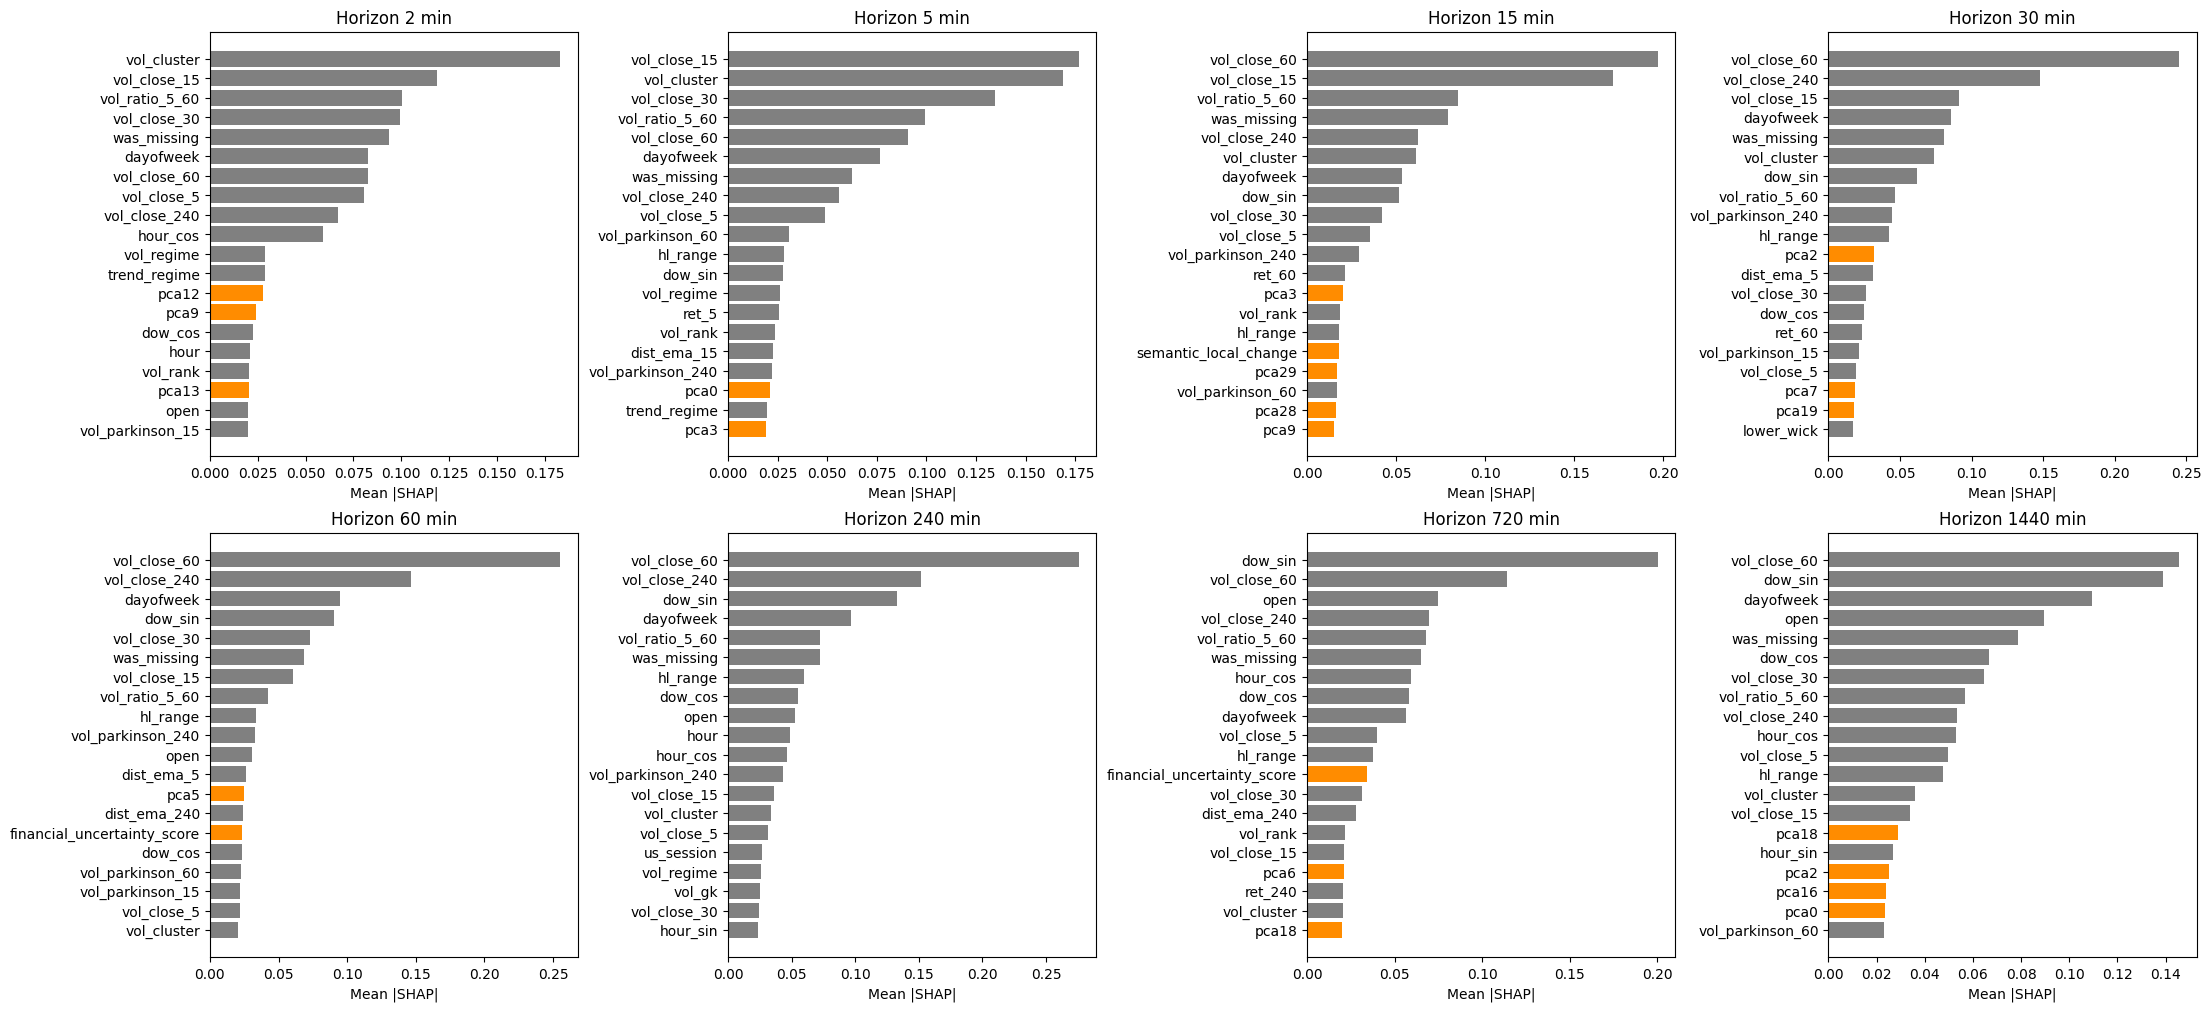

In [ ]:
model_importances = build_shap_summary(results_df, top_n=20)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def build_shap_summary(results_df, top_n=15):

    rows = []

    for _, r in results_df.iterrows():

        for feat in r["feature_importance"]:

            rows.append({

                "target": r["target"],
                "feature_set": r["feature_set"],
                "model": r["model"],
                "feature": feat["feature"],
                "mean_abs_shap": feat["mean_abs_shap"]

            })

    shap_df = pd.DataFrame(rows)

    # =====================================
    # Aggregation pro Modell
    # =====================================

    model_importances = {}

    for model in ["logreg", "xgboost", "mlp"]:

        tmp = (
            shap_df[shap_df["model"] == model]
            .groupby("feature")["mean_abs_shap"]
            .mean()
            .sort_values(ascending=False)
            .head(top_n)
            .reset_index()
        )

        model_importances[model] = tmp

    # =====================================
    # Plot
    # =====================================

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 8),
        constrained_layout=True
    )

    titles = {
        "logreg": "Logistic Regression",
        "xgboost": "XGBoost",
        "mlp": "MLP"
    }

    for ax, model in zip(axes, ["logreg", "xgboost", "mlp"]):

        df_plot = model_importances[model]
        bar_colors = [
            "darkorange" if (f in tweet_features or str(f).startswith("pca")) else "gray" for f in df_plot["feature"][::-1]
        ]

        ax.barh(
            df_plot["feature"][::-1],
            df_plot["mean_abs_shap"][::-1],
            color=bar_colors
        )

        ax.set_title(titles[model])
        ax.set_xlabel("Mean |SHAP|")

    plt.show()

    return model_importances

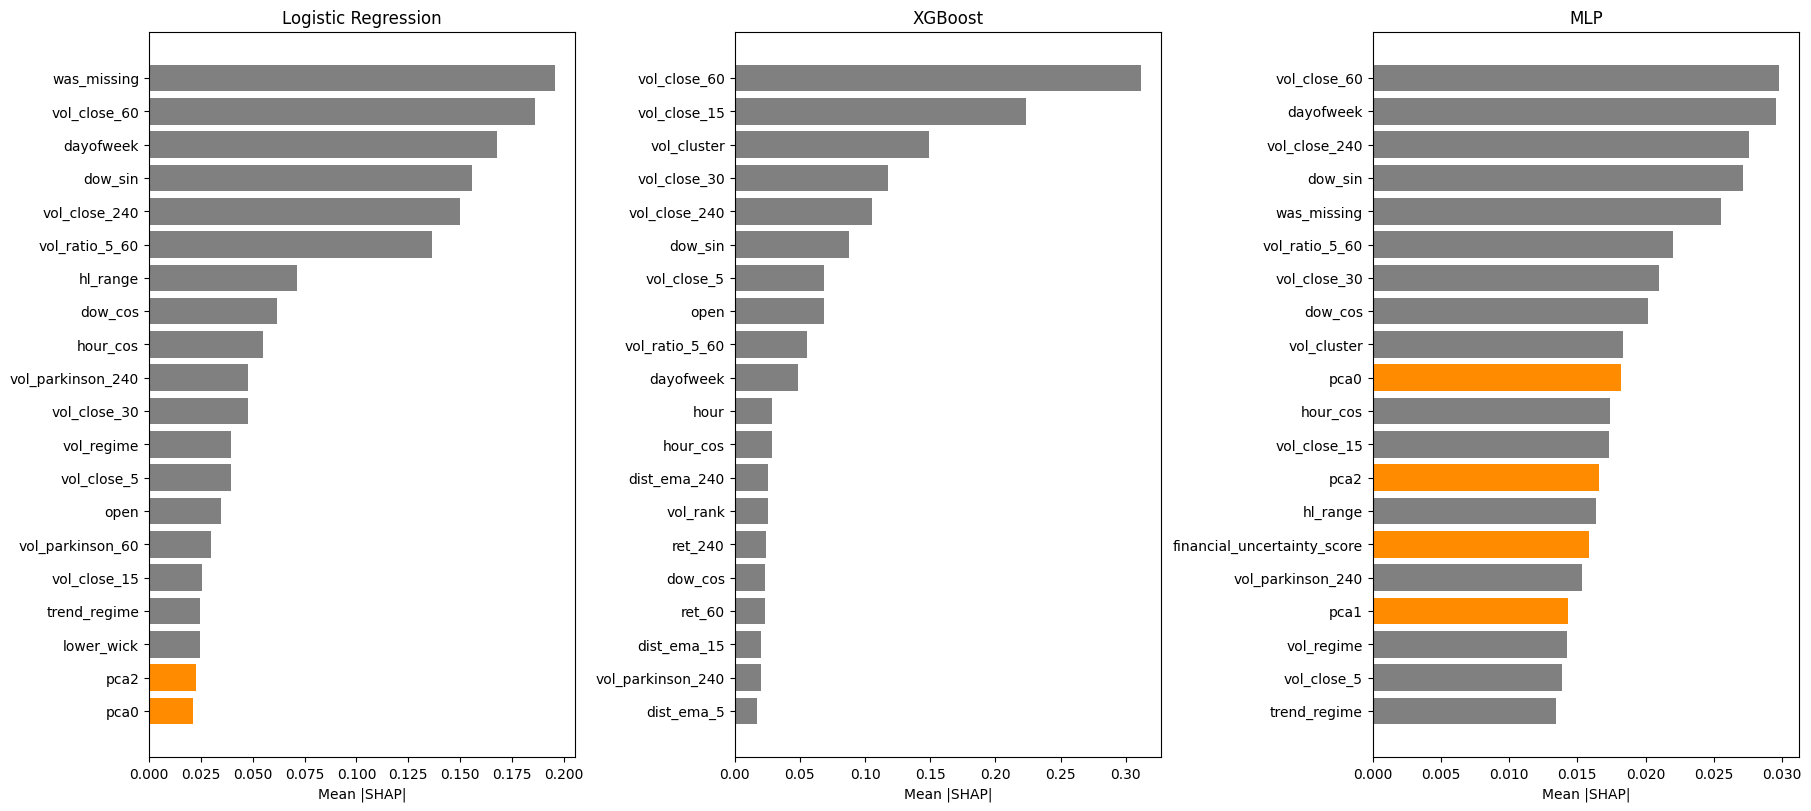

In [ ]:
model_importances = build_shap_summary(results_df, top_n=20)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def build_shap_summary(results_df, top_n=20):

    rows = []

    for _, r in results_df.iterrows():

        for feat in r["feature_importance"]:

            rows.append({

                "target": r["target"],
                "feature_set": r["feature_set"],
                "model": r["model"],
                "feature": feat["feature"],
                "mean_abs_shap": feat["mean_abs_shap"]

            })

    shap_df = pd.DataFrame(rows)


    # =====================================
    # Globale Feature Importance
    # =====================================

    global_importance = (
        shap_df
        .groupby("feature")["mean_abs_shap"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )


    # =====================================
    # Tweet Feature Filter
    # =====================================

    # tweet_keywords = [

    #     "finbert",
    #     "sentiment",
    #     "tweet",
    #     "topic",
    #     "semantic",
    #     "embedding",
    #     "policy",
    #     "risk",
    #     "energy",
    #     "geopolitical",
    #     "uncertainty",
    #     "market_aggression",
    #     "wti_",
    #     "trump"

    # ]


    # tweet_mask = (
    #     shap_df["feature"]
    #     .str.lower()
    #     .apply(
    #         lambda x:
    #         any(k in x for k in tweet_keywords)
    #     )
    # )


    # tweet_importance = (
    #     shap_df[tweet_mask]
    #     .groupby("feature")["mean_abs_shap"]
    #     .mean()
    #     .sort_values(ascending=False)
    #     .head(top_n)
    #     .reset_index()
    # )
    # =====================================
    # Tweet Feature Filter
    # =====================================

    tweet_keywords = [

        "finbert",
        "sentiment",
        "tweet",
        "topic",
        "semantic",
        "embedding",
        "emb_",
        "pca",
        "policy",
        "risk",
        "energy",
        "geopolitical",
        "uncertainty",
        "market_aggression",
        "wti_",
        "trump"

    ]


    tweet_mask = (
        shap_df["feature"]
        .str.lower()
        .apply(
            lambda x:
            any(k in x for k in tweet_keywords)
        )
    )


    tweet_importance = (
        shap_df[tweet_mask]
        .groupby("feature")["mean_abs_shap"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    # =====================================
    # Plot
    # =====================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 8)
    )


    # ---------------------
    # Global
    # ---------------------

    axes[0].barh(
        global_importance["feature"][::-1],
        global_importance["mean_abs_shap"][::-1]
    )

    axes[0].set_title(
        "Top 20 Global Features"
    )

    axes[0].set_xlabel(
        "Mean |SHAP|"
    )


    # ---------------------
    # Tweet only
    # ---------------------

    axes[1].barh(
        tweet_importance["feature"][::-1],
        tweet_importance["mean_abs_shap"][::-1]
    )

    axes[1].set_title(
        "Top 20 Tweet-Based Features"
    )

    axes[1].set_xlabel(
        "Mean |SHAP|"
    )


    plt.tight_layout()
    plt.show()


    return {
        "global": global_importance,
        "tweet_features": tweet_importance
    }

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def build_shap_summary(results_df, top_n=20):

    rows = []

    for _, r in results_df.iterrows():

        for feat in r["feature_importance"]:

            rows.append({

                "target": r["target"],
                "feature_set": r["feature_set"],
                "model": r["model"],
                "feature": feat["feature"],
                "mean_abs_shap": feat["mean_abs_shap"]

            })

    shap_df = pd.DataFrame(rows)

    # ==================================================
    # Alle expliziten Tweet Features
    # ==================================================

    tweet_features = {

        'finbert_positive',
        'finbert_neutral',
        'finbert_negative',
        'finbert_sentiment_score',
        'finbert_entropy',
        'finbert_confidence',
        'financial_uncertainty_score',
        'financial_risk_sentiment',
        'finbert_polarization',

        'caps_ratio',
        'exclamation_count',
        'exclamation_count_log',
        'tweet_length',
        'tweet_length_log',
        'market_aggression_index',

        'time_since_last_tweet_min',
        'rolling_tweet_frequency_60m',
        'rolling_tweet_frequency_6h',
        'rolling_tweet_frequency_24h',
        'tweet_burst_indicator',
        'tweet_acceleration_6h',

        'sentiment_delta_vs_previous',
        'rolling_sentiment_mean_60m',
        'rolling_sentiment_std_60m',

        'is_trump_president',

        'wti_bullish_score',
        'wti_bearish_score',

        'energy_supply_score',
        'geopolitical_oil_risk_score',
        'usd_strength_pressure_score',
        'fed_monetary_policy_score',
        'risk_sentiment_score',

        'trump_energy_policy_score',
        'trump_market_shock_language_score',
        'policy_shock_score',

        'topic_concentration',
        'topic_energy_supply',
        'topic_fed_monetary_policy',
        'topic_geopolitical_oil_risk',
        'topic_policy_shock',
        'topic_risk_sentiment',
        'topic_trump_energy_policy',
        'topic_trump_market_shock_language',
        'topic_usd_strength_pressure',
        'topic_wti_bearish',
        'topic_wti_bullish',

        'semantic_global_novelty',
        'semantic_local_change',
        'semantic_rolling_novelty'
    }

    # ==================================================
    # Global Importance
    # ==================================================

    global_importance = (
        shap_df
        .groupby("feature")["mean_abs_shap"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    # ==================================================
    # Tweet Feature Importance
    # ==================================================

    tweet_mask = (
        shap_df["feature"].isin(tweet_features)
        |
        shap_df["feature"].str.contains(
            r"pca|emb_",
            case=False,
            regex=True,
            na=False
        )
    )

    tweet_importance = (
        shap_df[tweet_mask]
        .groupby("feature")["mean_abs_shap"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    # ==================================================
    # Plot
    # ==================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 8),
        constrained_layout=True
    )

    bar_colors = [
        "darkorange"
        if (
            f in tweet_features
            or str(f).startswith("pca")
            or str(f).startswith("emb_")
        )
        else "gray"
        for f in global_importance["feature"][::-1]
    ]
    axes[0].barh(
        global_importance["feature"][::-1],
        global_importance["mean_abs_shap"][::-1],
        color=bar_colors
    )

    axes[0].set_title(
        f"Top {top_n} Global Features"
    )

    axes[0].set_xlabel(
        "Mean |SHAP|"
    )
    
    axes[1].barh(
        tweet_importance["feature"][::-1],
        tweet_importance["mean_abs_shap"][::-1],
        color="darkorange"        
    )

    axes[1].set_title(
        f"Top {top_n} Tweet-Based Features"
    )

    axes[1].set_xlabel(
        "Mean |SHAP|"
    )

    plt.show()

    return {
        "global": global_importance,
        "tweet_features": tweet_importance
    }

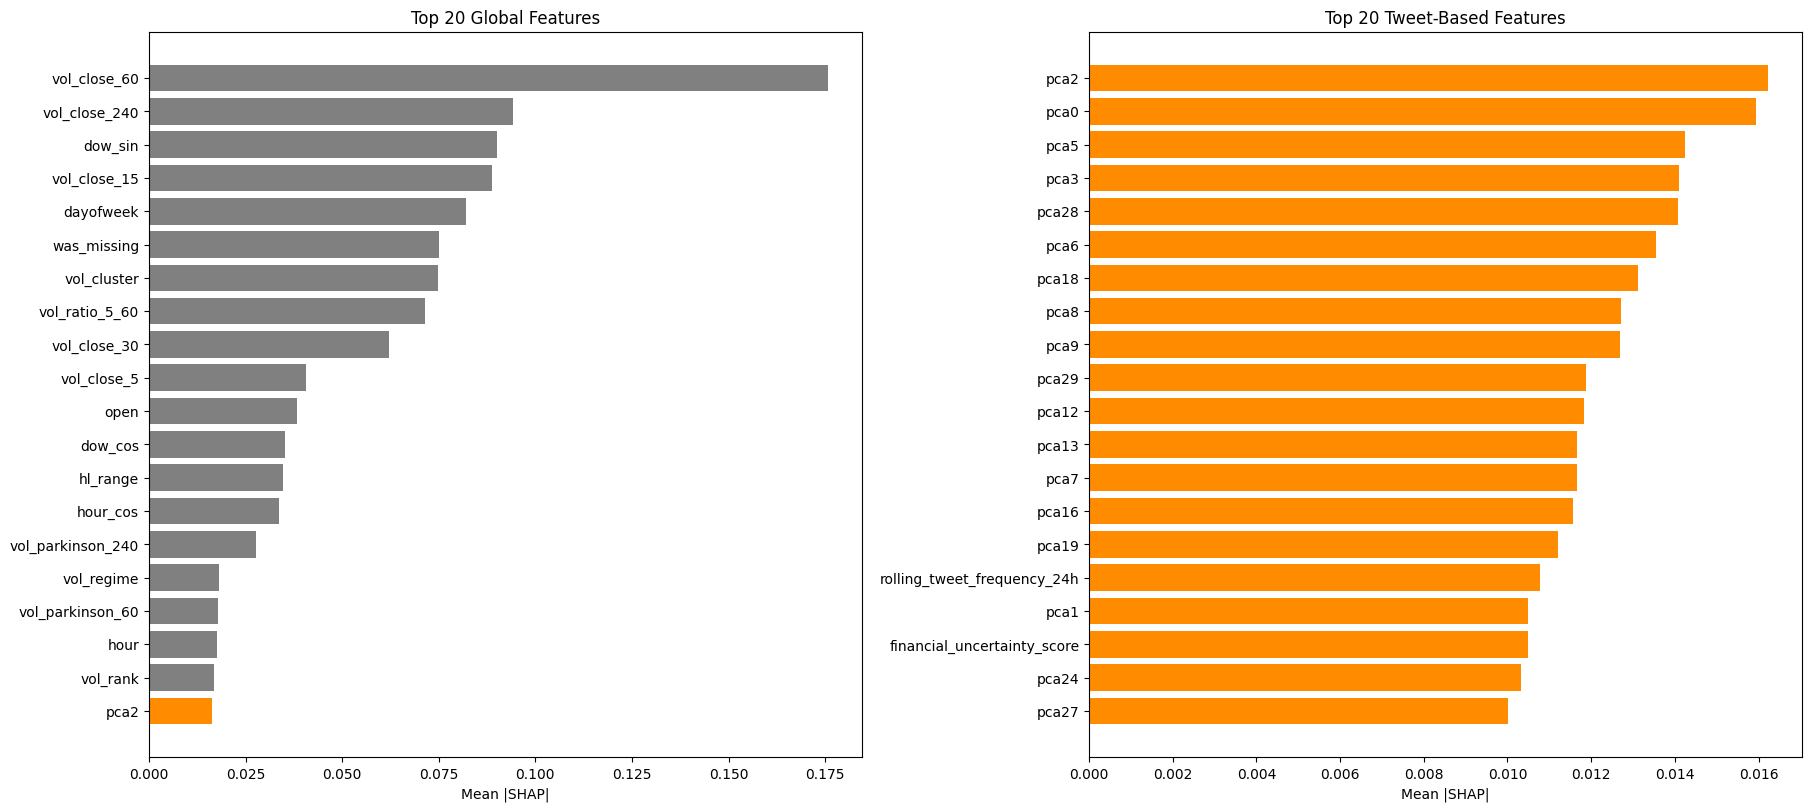

In [ ]:
shap_summary = build_shap_summary(results_df, top_n=20)

In [ ]:
tweets.columns

Index(['timestamp_utc', 'clean_text', 'embedding', 'finbert_positive',
       'finbert_neutral', 'finbert_negative', 'finbert_sentiment_score',
       'finbert_entropy', 'finbert_confidence', 'financial_uncertainty_score',
       'financial_risk_sentiment', 'finbert_polarization', 'caps_ratio',
       'exclamation_count', 'exclamation_count_log', 'tweet_length',
       'tweet_length_log', 'market_aggression_index',
       'time_since_last_tweet_min', 'rolling_tweet_frequency_60m',
       'rolling_tweet_frequency_6h', 'rolling_tweet_frequency_24h',
       'tweet_burst_indicator', 'tweet_acceleration_6h',
       'sentiment_delta_vs_previous', 'rolling_sentiment_mean_60m',
       'rolling_sentiment_std_60m', 'is_trump_president', 'wti_bullish_score',
       'wti_bearish_score', 'energy_supply_score',
       'geopolitical_oil_risk_score', 'usd_strength_pressure_score',
       'fed_monetary_policy_score', 'risk_sentiment_score',
       'trump_energy_policy_score', 'trump_market_shock_langua

In [ ]:
def plot_top_features(shap_df, top_n=20):

    d = shap_df.head(top_n)

    plt.figure(figsize=(8,8))

    sns.barplot(
        data=d,
        x="mean_abs_shap",
        y="feature"
    )

    plt.title(
        "Top Global Features"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
baseline_features = set([
    'open',
    'high',
    'low',
    'close',
    'was_missing',
    ...
])

In [ ]:
def tweet_importance_by_horizon(results_df):

    rows = []

    for _, r in results_df.iterrows():

        if r["feature_set"] != "enhanced":
            continue

        tweet_imp = 0

        for feat in r["feature_importance"]:

            if feat["feature"] not in baseline_features:

                tweet_imp += feat["mean_abs_shap"]

        rows.append({

            "target":
                r["target"],

            "model":
                r["model"],

            "tweet_importance":
                tweet_imp
        })

    return pd.DataFrame(rows)

In [ ]:
def plot_tweet_importance(df):

    tmp = (
        df
        .groupby("target")
        ["tweet_importance"]
        .mean()
        .reset_index()
    )

    tmp["horizon"] = (
        tmp["target"]
        .str.extract(r"(\d+)")
        .astype(int)
    )

    plt.figure(figsize=(10,5))

    plt.plot(
        tmp["horizon"],
        tmp["tweet_importance"],
        marker="o"
    )

    plt.xscale("log")

    plt.xlabel(
        "Forecast Horizon (min)"
    )

    plt.ylabel(
        "Total Tweet SHAP Importance"
    )

    plt.title(
        "Importance of Tweet Features by Horizon"
    )

    plt.tight_layout()
    plt.show()

In [267]:
summary

,target,feature_set,model,mean_auc,std_auc,n
0,y_up_1440,baseline,logreg,0.622124,0.017323,5
1,y_up_1440,baseline,mlp,0.610912,0.026363,5
2,y_up_1440,baseline,xgboost,0.622812,0.036279,5
3,y_up_1440,enhanced,logreg,0.618640,0.014919,5
4,y_up_1440,enhanced,mlp,0.595781,0.010132,5
5,y_up_1440,enhanced,xgboost,0.617144,0.033751,5
6,y_up_15,baseline,logreg,0.718415,0.009590,5
7,y_up_15,baseline,mlp,0.709848,0.021663,5
8,y_up_15,baseline,xgboost,0.719823,0.019266,5
9,y_up_15,enhanced,logreg,0.709078,0.019587,5


In [268]:
final_results

,target,feature_set,model,auc,auc_ci,ci_lower,ci_upper,horizon
0,y_up_2,baseline,logreg,0.720626,0.720626,0.704693,0.736735,2
1,y_up_2,baseline,xgboost,0.755636,0.755636,0.742838,0.769515,2
2,y_up_2,baseline,mlp,0.728901,0.728901,0.714444,0.743095,2
3,y_up_2,enhanced,logreg,0.717263,0.717263,0.701689,0.733211,2
4,y_up_2,enhanced,xgboost,0.750746,0.750746,0.736792,0.764408,2
5,y_up_2,enhanced,mlp,0.733837,0.733837,0.719324,0.748187,2
6,y_up_5,baseline,logreg,0.708313,0.708313,0.692416,0.723419,5
7,y_up_5,baseline,xgboost,0.749706,0.749706,0.736142,0.763331,5
8,y_up_5,baseline,mlp,0.724919,0.724919,0.710133,0.739388,5
9,y_up_5,enhanced,logreg,0.707668,0.707668,0.691686,0.724159,5


In [271]:
final_summary

,target,model,delta_auc,delta_ci_low,delta_ci_high,p_value,p_value_clean,significance
0,y_up_2,logreg,-0.003363,-0.009292,0.002201,2.265058e-01,0.227,n.s.
1,y_up_2,xgboost,-0.004890,-0.015755,0.005432,3.504381e-01,0.350,n.s.
2,y_up_2,mlp,0.004935,-0.010173,0.020013,5.249536e-01,0.525,n.s.
3,y_up_5,logreg,-0.000645,-0.005213,0.003875,7.767401e-01,0.777,n.s.
4,y_up_5,xgboost,-0.001068,-0.010123,0.007792,8.155492e-01,0.816,n.s.
5,y_up_5,mlp,0.002312,-0.011476,0.015546,7.395313e-01,0.740,n.s.
6,y_up_15,logreg,-0.003963,-0.010056,0.002016,1.971440e-01,0.197,n.s.
7,y_up_15,xgboost,0.008636,-0.002191,0.019105,1.186815e-01,0.119,n.s.
8,y_up_15,mlp,-0.010604,-0.024247,0.003624,1.390314e-01,0.139,n.s.
9,y_up_30,logreg,-0.002016,-0.007005,0.003182,4.363775e-01,0.436,n.s.


In [ ]:
su

In [290]:
def plot_delta_boxplots(delta_df):

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=final_summary,
        x="target",
        y="delta_auc",
        #hue="model"
    )

    plt.axhline(
        0,
        color="red",
        linestyle="--"
    )

    plt.xticks(rotation=45)

    plt.ylabel("Delta AUC")

    plt.title(
        #"Distribution of Tweet Effect Across CV Folds"
        "Delta AUC Across Targets"
    )

    plt.tight_layout()
    plt.show()

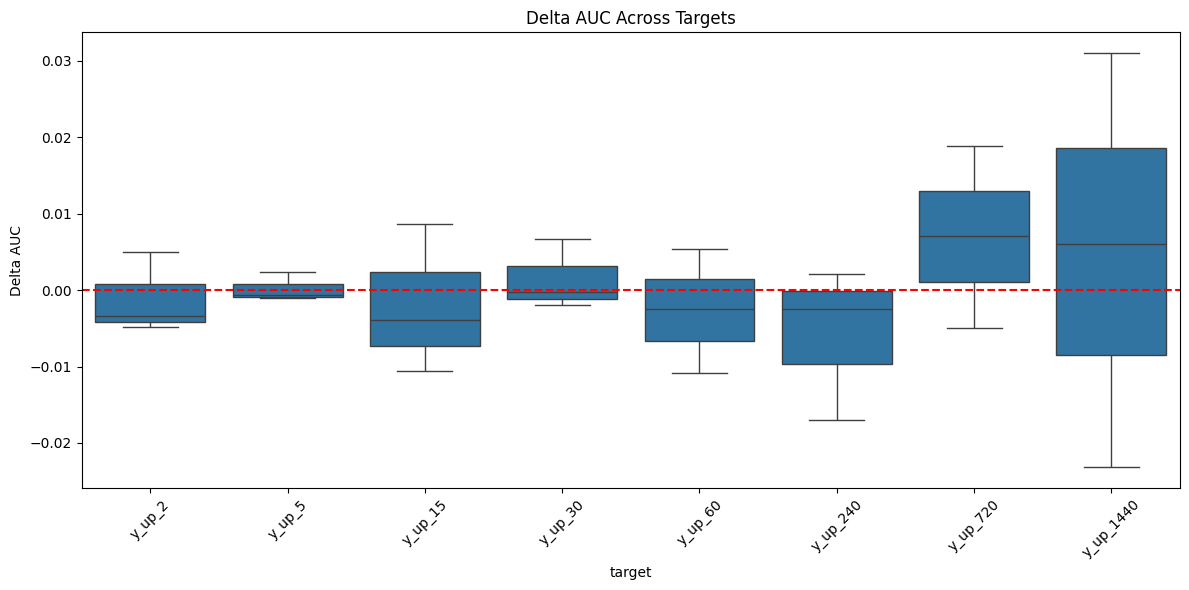

In [291]:
plot_delta_boxplots(delta_df)

In [ ]:
def plot_delta_boxplots(delta_df):

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=final_results,
        x="feature_set",
        y="auc",
        #hue="model"
    )

    # plt.axhline(
    #     0,
    #     color="red",
    #     linestyle="--"
    # )

    plt.xticks(rotation=45)

    plt.ylabel("Mean AUC")

    plt.title(
        #"Distribution of Tweet Effect Across CV Folds"
        "Dist of 5-Fold Mean AUC Across Feature-Sets"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
delta_df

,target,model,fold,baseline_auc,enhanced_auc,delta_auc,delta_auc_pct
0,y_up_2,logreg,0,0.730147,0.722964,-0.007183,-0.009838
1,y_up_2,logreg,1,0.757946,0.748333,-0.009613,-0.012682
2,y_up_2,logreg,2,0.752789,0.758338,0.005549,0.007371
3,y_up_2,logreg,3,0.745461,0.746307,0.000846,0.001135
4,y_up_2,logreg,4,0.761319,0.758957,-0.002362,-0.003103
...,...,...,...,...,...,...,...
115,y_up_1440,mlp,0,0.640434,0.610392,-0.030042,-0.046909
116,y_up_1440,mlp,1,0.602455,0.602119,-0.000335,-0.000556
117,y_up_1440,mlp,2,0.588531,0.587285,-0.001246,-0.002117
118,y_up_1440,mlp,3,0.585731,0.587651,0.001920,0.003278


In [ ]:
summary

,target,feature_set,model,mean_auc,std_auc,n
0,y_up_1440,baseline,logreg,0.622124,0.017323,5
1,y_up_1440,baseline,mlp,0.610912,0.026363,5
2,y_up_1440,baseline,xgboost,0.622812,0.036279,5
3,y_up_1440,enhanced,logreg,0.618640,0.014919,5
4,y_up_1440,enhanced,mlp,0.595781,0.010132,5
5,y_up_1440,enhanced,xgboost,0.617144,0.033751,5
6,y_up_15,baseline,logreg,0.718415,0.009590,5
7,y_up_15,baseline,mlp,0.709848,0.021663,5
8,y_up_15,baseline,xgboost,0.719823,0.019266,5
9,y_up_15,enhanced,logreg,0.709078,0.019587,5


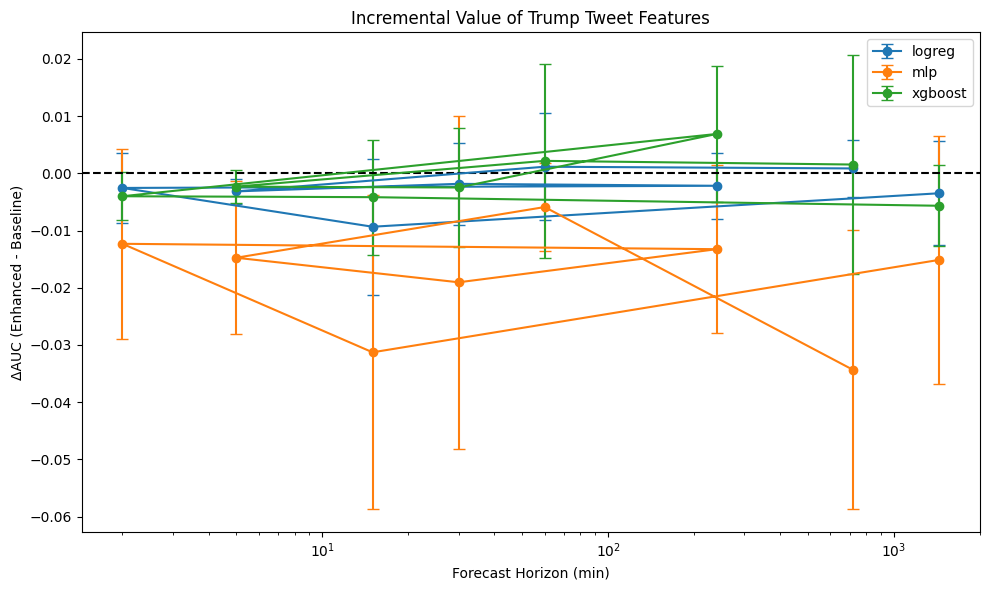

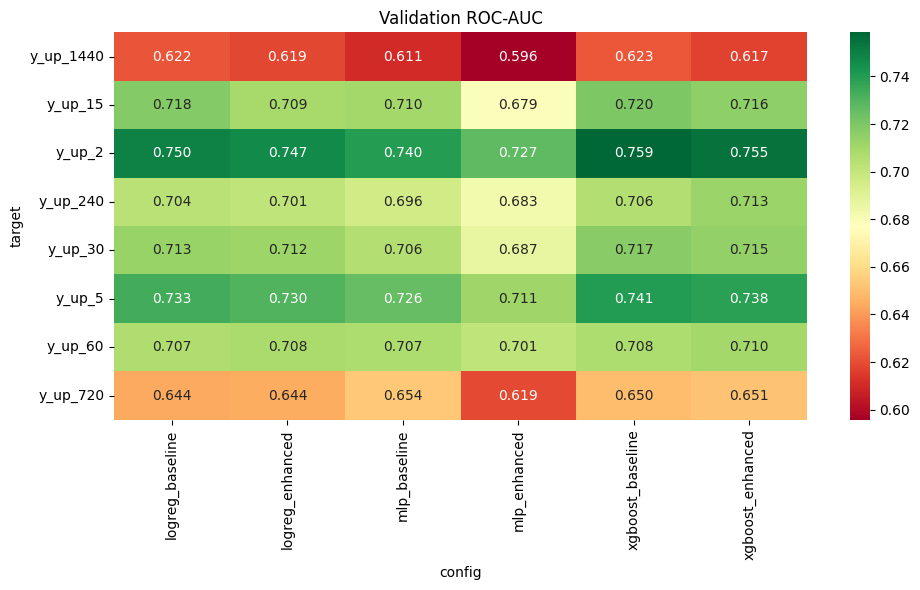

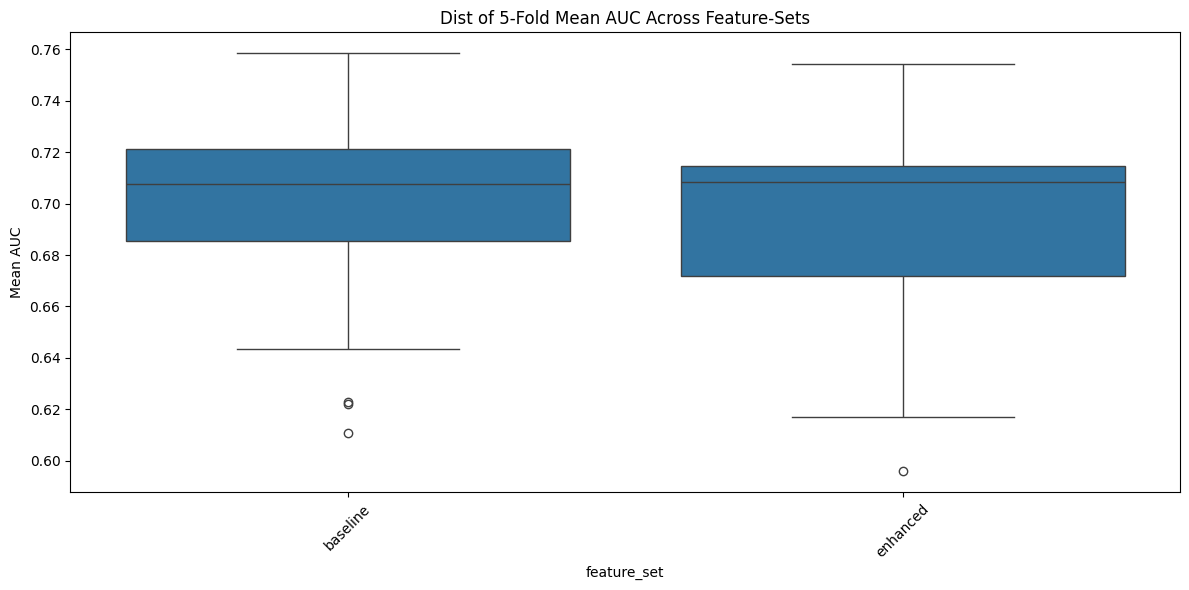

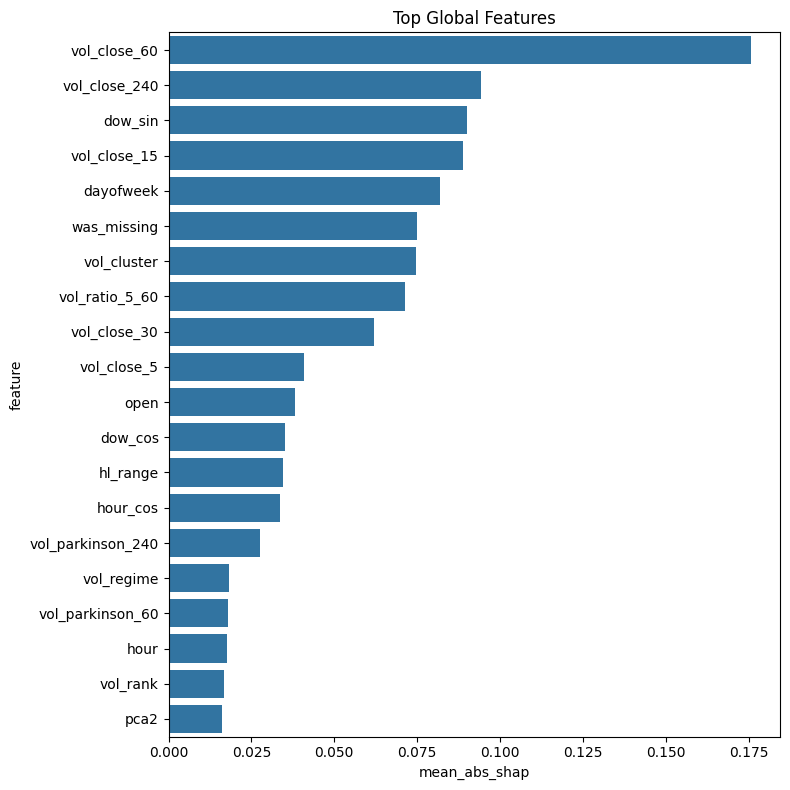

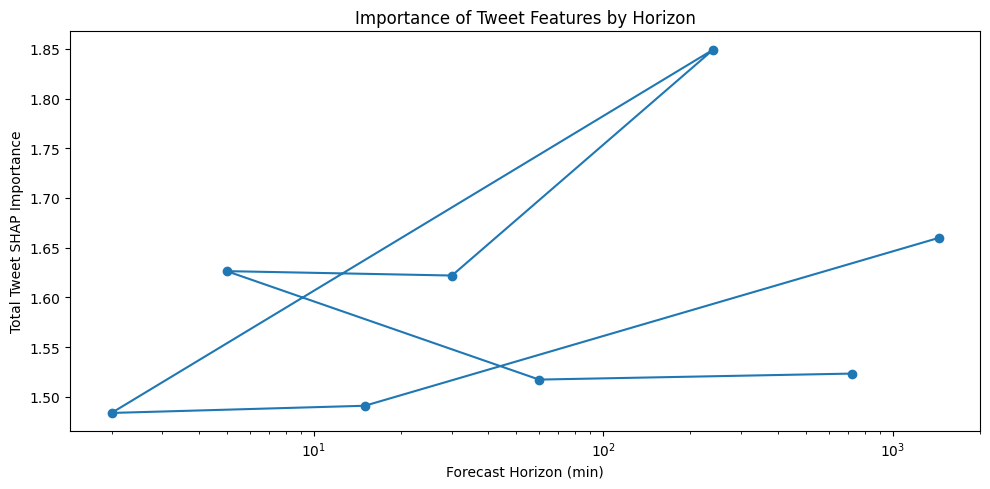

,target,model,mean_delta_auc,std_delta_auc,p_value
0,y_up_1440,logreg,-0.003484,0.009126,0.4375
1,y_up_1440,mlp,-0.015131,0.021649,0.3125
2,y_up_1440,xgboost,-0.005669,0.007046,0.1875
3,y_up_15,logreg,-0.009337,0.011870,0.0625
4,y_up_15,mlp,-0.031293,0.027460,0.0625
5,y_up_15,xgboost,-0.004165,0.010032,0.4375
6,y_up_2,logreg,-0.002553,0.006093,0.4375
7,y_up_2,mlp,-0.012319,0.016576,0.1875
8,y_up_2,xgboost,-0.004006,0.004233,0.0625
9,y_up_240,logreg,-0.002175,0.005759,0.6250


In [ ]:
summary = build_performance_summary(results_df)

delta_df = build_delta_auc(results_df)

significance = test_tweet_effect(delta_df)

shap_summary = build_shap_summary(results_df)

tweet_imp = tweet_importance_by_horizon(results_df)

plot_delta_auc(delta_df)

plot_auc_heatmap(summary)

plot_delta_boxplots(delta_df)

plot_top_features(shap_summary)

plot_tweet_importance(tweet_imp)

display(significance)

In [ ]:
tweets.columns

Index(['timestamp_utc', 'clean_text', 'embedding', 'finbert_positive',
       'finbert_neutral', 'finbert_negative', 'finbert_sentiment_score',
       'finbert_entropy', 'finbert_confidence', 'financial_uncertainty_score',
       'financial_risk_sentiment', 'finbert_polarization', 'caps_ratio',
       'exclamation_count', 'exclamation_count_log', 'tweet_length',
       'tweet_length_log', 'market_aggression_index',
       'time_since_last_tweet_min', 'rolling_tweet_frequency_60m',
       'rolling_tweet_frequency_6h', 'rolling_tweet_frequency_24h',
       'tweet_burst_indicator', 'tweet_acceleration_6h',
       'sentiment_delta_vs_previous', 'rolling_sentiment_mean_60m',
       'rolling_sentiment_std_60m', 'is_trump_president', 'wti_bullish_score',
       'wti_bearish_score', 'energy_supply_score',
       'geopolitical_oil_risk_score', 'usd_strength_pressure_score',
       'fed_monetary_policy_score', 'risk_sentiment_score',
       'trump_energy_policy_score', 'trump_market_shock_langua

# 2. Versuch

In [ ]:
import pandas as pd
import numpy as np

summary_df = (
    results_df
    .groupby(
        ["target", "feature_set", "model"],
        as_index=False
    )
    .agg(
        mean_auc=("val_auc", "mean"),
        std_auc=("val_auc", "std"),
        min_auc=("val_auc", "min"),
        max_auc=("val_auc", "max")
    )
)

summary_df.head()

,target,feature_set,model,mean_auc,std_auc,min_auc,max_auc
0,y_up_1440,baseline,logreg,0.622124,0.017323,0.605623,0.645664
1,y_up_1440,baseline,mlp,0.610912,0.026363,0.585731,0.640434
2,y_up_1440,baseline,xgboost,0.622812,0.036279,0.584541,0.678122
3,y_up_1440,enhanced,logreg,0.618640,0.014919,0.595333,0.632372
4,y_up_1440,enhanced,mlp,0.595781,0.010132,0.587285,0.610392


In [ ]:
baseline = (
    summary_df[summary_df["feature_set"] == "baseline"]
    .rename(columns={"mean_auc": "auc_baseline"})
)

enhanced = (
    summary_df[summary_df["feature_set"] == "enhanced"]
    .rename(columns={"mean_auc": "auc_enhanced"})
)

delta_df = baseline.merge(
    enhanced,
    on=["target", "model"],
    suffixes=("_base", "_enh")
)

delta_df["delta_auc"] = (
    delta_df["auc_enhanced"]
    - delta_df["auc_baseline"]
)

delta_df = delta_df[
    ["target", "model", "auc_baseline",
     "auc_enhanced", "delta_auc"]
]

delta_df.head()

,target,model,auc_baseline,auc_enhanced,delta_auc
0,y_up_1440,logreg,0.622124,0.618640,-0.003484
1,y_up_1440,mlp,0.610912,0.595781,-0.015131
2,y_up_1440,xgboost,0.622812,0.617144,-0.005669
3,y_up_15,logreg,0.718415,0.709078,-0.009337
4,y_up_15,mlp,0.709848,0.678555,-0.031293


In [255]:
final_results

,target,feature_set,model,auc,auc_ci,ci_lower,ci_upper
0,y_up_2,baseline,logreg,0.720626,0.720626,0.704693,0.736735
1,y_up_2,baseline,xgboost,0.755636,0.755636,0.742838,0.769515
2,y_up_2,baseline,mlp,0.728901,0.728901,0.714444,0.743095
3,y_up_2,enhanced,logreg,0.717263,0.717263,0.701689,0.733211
4,y_up_2,enhanced,xgboost,0.750746,0.750746,0.736792,0.764408
5,y_up_2,enhanced,mlp,0.733837,0.733837,0.719324,0.748187
6,y_up_5,baseline,logreg,0.708313,0.708313,0.692416,0.723419
7,y_up_5,baseline,xgboost,0.749706,0.749706,0.736142,0.763331
8,y_up_5,baseline,mlp,0.724919,0.724919,0.710133,0.739388
9,y_up_5,enhanced,logreg,0.707668,0.707668,0.691686,0.724159


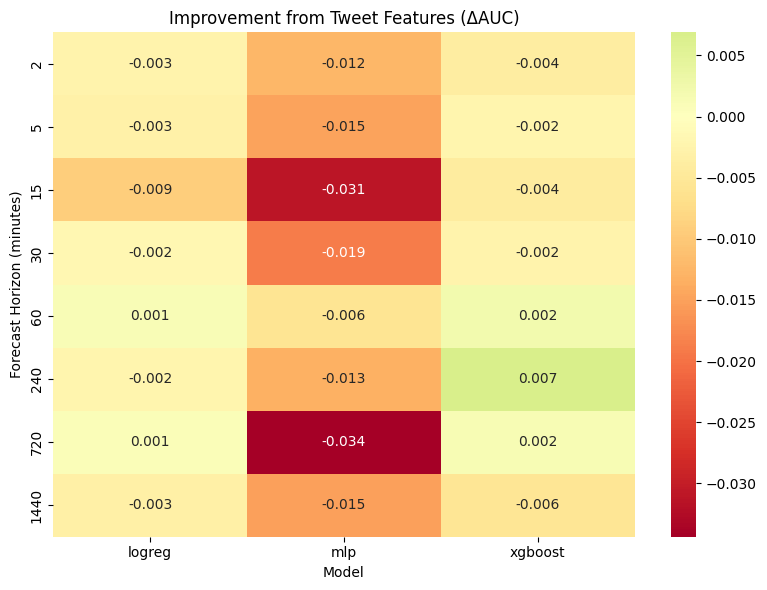

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = delta_df.pivot(
    index="horizon",
    columns="model",
    values="delta_auc"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".3f"
)

plt.title(
    "Improvement from Tweet Features (ΔAUC)"
)

plt.ylabel("Forecast Horizon (minutes)")
plt.xlabel("Model")

plt.tight_layout()

plt.savefig(
    "heatmap_delta_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [248]:
final_results

,target,feature_set,model,auc,auc_ci,ci_lower,ci_upper
0,y_up_2,baseline,logreg,0.720626,0.720626,0.704693,0.736735
1,y_up_2,baseline,xgboost,0.755636,0.755636,0.742838,0.769515
2,y_up_2,baseline,mlp,0.728901,0.728901,0.714444,0.743095
3,y_up_2,enhanced,logreg,0.717263,0.717263,0.701689,0.733211
4,y_up_2,enhanced,xgboost,0.750746,0.750746,0.736792,0.764408
5,y_up_2,enhanced,mlp,0.733837,0.733837,0.719324,0.748187
6,y_up_5,baseline,logreg,0.708313,0.708313,0.692416,0.723419
7,y_up_5,baseline,xgboost,0.749706,0.749706,0.736142,0.763331
8,y_up_5,baseline,mlp,0.724919,0.724919,0.710133,0.739388
9,y_up_5,enhanced,logreg,0.707668,0.707668,0.691686,0.724159


KeyError: 'horizon'

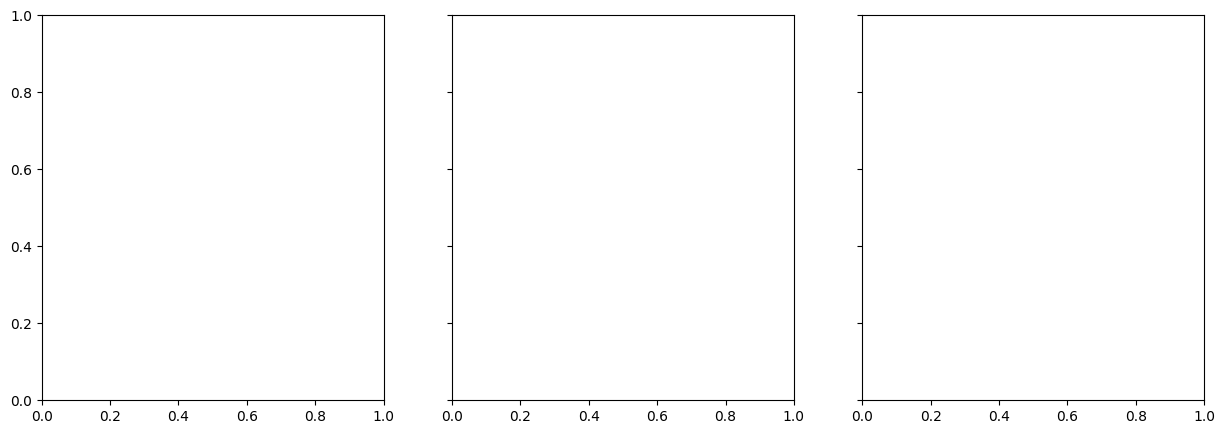

In [256]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5),
    sharey=True
)

models = ["logreg", "xgboost", "mlp"]

for ax, model in zip(axes, models):

    tmp = final_results[
        final_results["model"] == model
    ]

    for fs in ["baseline", "enhanced"]:

        subset = (
            tmp[tmp["feature_set"] == fs]
            .sort_values("horizon")
        )

        ax.plot(
            subset["target"],
            subset["auc"],
            marker="o",
            label=fs
        )

    ax.set_title(model.upper())
    ax.set_xlabel("Forecast Horizon (min)")
    ax.grid(True)

axes[0].set_ylabel("Mean Validation AUC")

plt.legend()

# plt.tight_layout()

# plt.savefig(
#     "auc_by_horizon.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [257]:
horizon = target.split("_")[-1]

In [264]:
final_results

,target,feature_set,model,auc,auc_ci,ci_lower,ci_upper,horizon
0,y_up_2,baseline,logreg,0.720626,0.720626,0.704693,0.736735,2
1,y_up_2,baseline,xgboost,0.755636,0.755636,0.742838,0.769515,2
2,y_up_2,baseline,mlp,0.728901,0.728901,0.714444,0.743095,2
3,y_up_2,enhanced,logreg,0.717263,0.717263,0.701689,0.733211,2
4,y_up_2,enhanced,xgboost,0.750746,0.750746,0.736792,0.764408,2
5,y_up_2,enhanced,mlp,0.733837,0.733837,0.719324,0.748187,2
6,y_up_5,baseline,logreg,0.708313,0.708313,0.692416,0.723419,5
7,y_up_5,baseline,xgboost,0.749706,0.749706,0.736142,0.763331,5
8,y_up_5,baseline,mlp,0.724919,0.724919,0.710133,0.739388,5
9,y_up_5,enhanced,logreg,0.707668,0.707668,0.691686,0.724159,5


In [ ]:
final_results = pd.read_pickle(r"")

In [263]:
final_results["horizon"] = (
    final_results["target"]
    .str.extract(r"(\d+)")
    .astype(int)
)


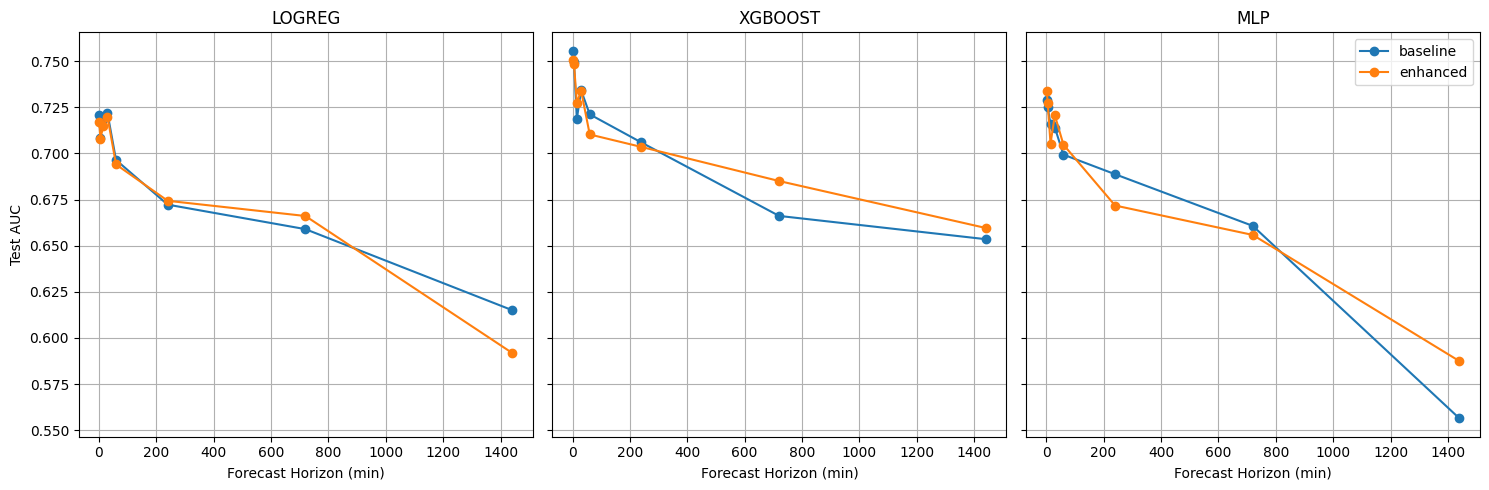

In [266]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5),
    sharey=True
)

models = ["logreg", "xgboost", "mlp"]

for ax, model in zip(axes, models):

    tmp = final_results[
        final_results["model"] == model
    ]

    for fs in ["baseline", "enhanced"]:

        subset = (
            tmp[tmp["feature_set"] == fs]
            .sort_values("horizon")
        )

        ax.plot(
            subset["horizon"],
            subset["auc"],
            marker="o",
            label=fs
        )

    ax.set_title(model.upper())
    ax.set_xlabel("Forecast Horizon (min)")
    ax.grid(True)

axes[0].set_ylabel("Test AUC")

plt.legend()

plt.tight_layout()

# plt.savefig(
#     "auc_by_horizon.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

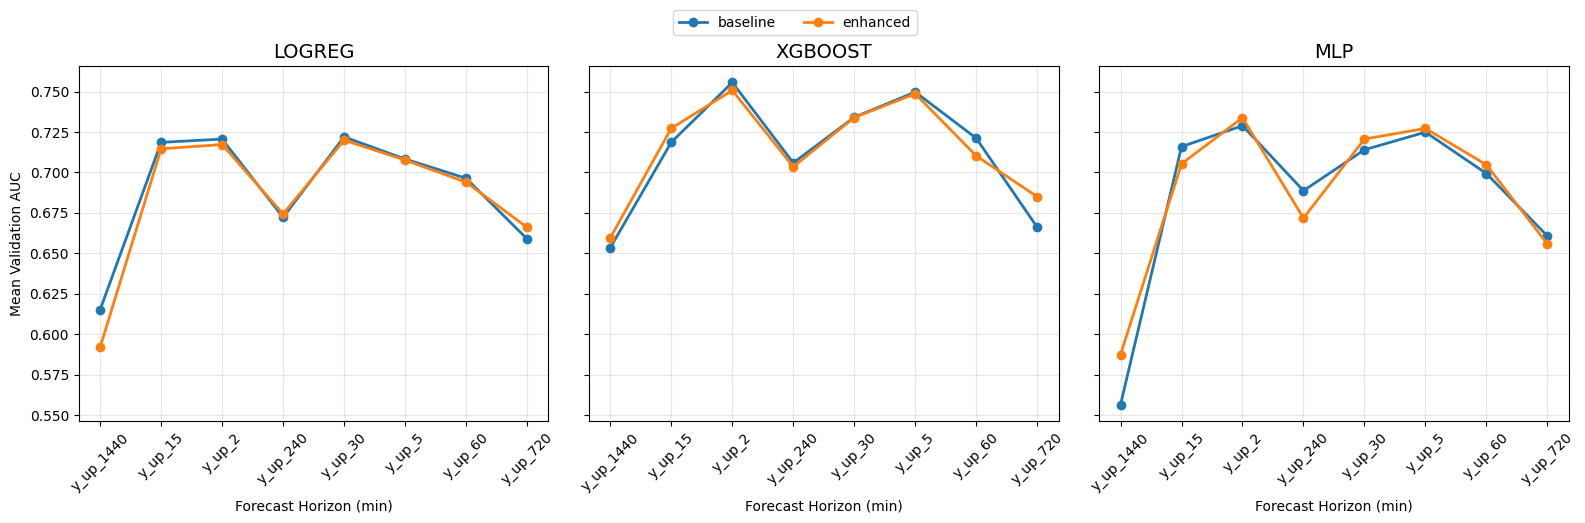

In [252]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharey=True
)

models = ["logreg", "xgboost", "mlp"]

for ax, model in zip(axes, models):

    tmp = final_results[
        final_results["model"] == model
    ]

    for fs in ["baseline", "enhanced"]:

        subset = (
            tmp[tmp["feature_set"] == fs]
            .sort_values("target")
        )

        ax.plot(
            subset["target"],
            subset["auc"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=fs
        )

    ax.set_title(model.upper(), fontsize=14)
    ax.set_xlabel("Forecast Horizon (min)")

    # X Labels lesbarer machen
    ax.tick_params(axis="x", rotation=45)

    # nur vorhandene Werte als ticks nutzen
    ax.set_xticks(tmp["target"].unique())

    ax.grid(
        True,
        alpha=0.3
    )

axes[0].set_ylabel("Mean Validation AUC")

# gemeinsame Legende oben
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.05)
)

# mehr Platz zwischen Plots
plt.subplots_adjust(
    wspace=0.15,
    top=0.82
)

plt.tight_layout()

plt.show()

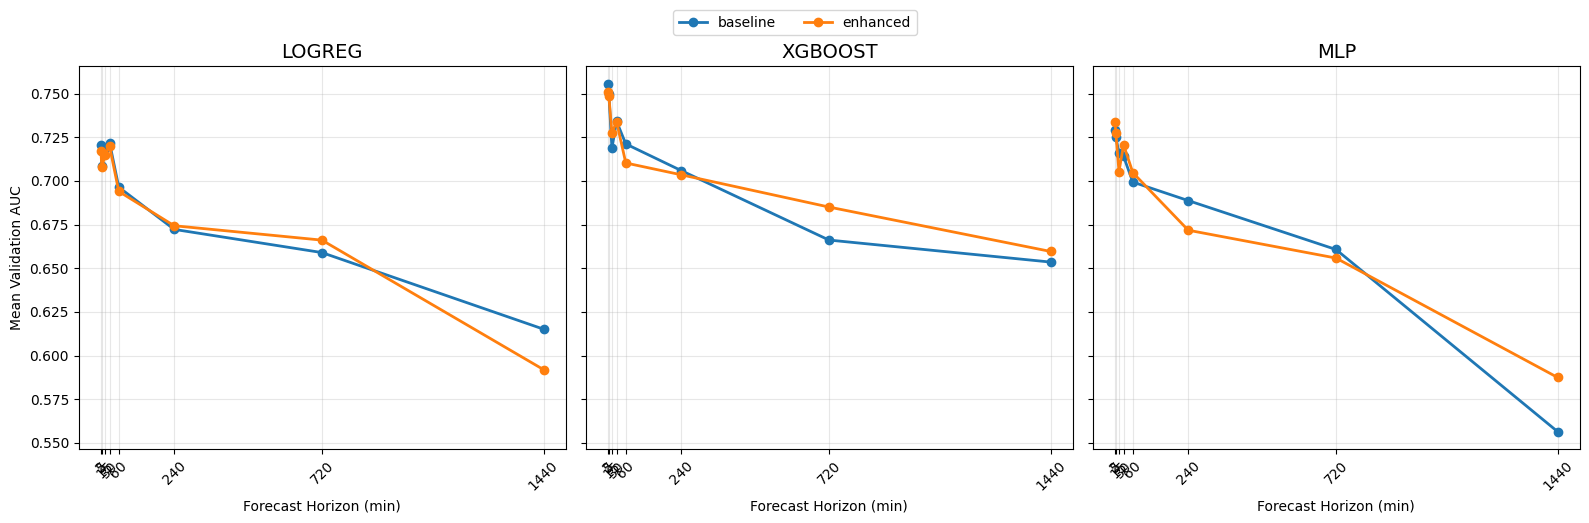

In [253]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharey=True
)

models = ["logreg", "xgboost", "mlp"]

for ax, model in zip(axes, models):

    tmp = final_results[
        final_results["model"] == model
    ].copy()

    # target numerisch machen (falls z.B. "30min" oder Strings vorhanden sind)
    tmp["target_num"] = (
        tmp["target"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(int)
    )

    for fs in ["baseline", "enhanced"]:

        subset = (
            tmp[tmp["feature_set"] == fs]
            .sort_values("target_num")
        )

        ax.plot(
            subset["target_num"],
            subset["auc"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=fs
        )

    ax.set_title(model.upper(), fontsize=14)
    ax.set_xlabel("Forecast Horizon (min)")

    # richtige zeitliche Reihenfolge der Labels
    ax.set_xticks(
        sorted(tmp["target_num"].unique())
    )

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.grid(
        True,
        alpha=0.3
    )

axes[0].set_ylabel("Mean Validation AUC")


# gemeinsame Legende
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.05)
)

plt.subplots_adjust(
    wspace=0.15,
    top=0.82
)

plt.tight_layout()

plt.show()

In [254]:
summary_df

NameError: name 'summary_df' is not defined

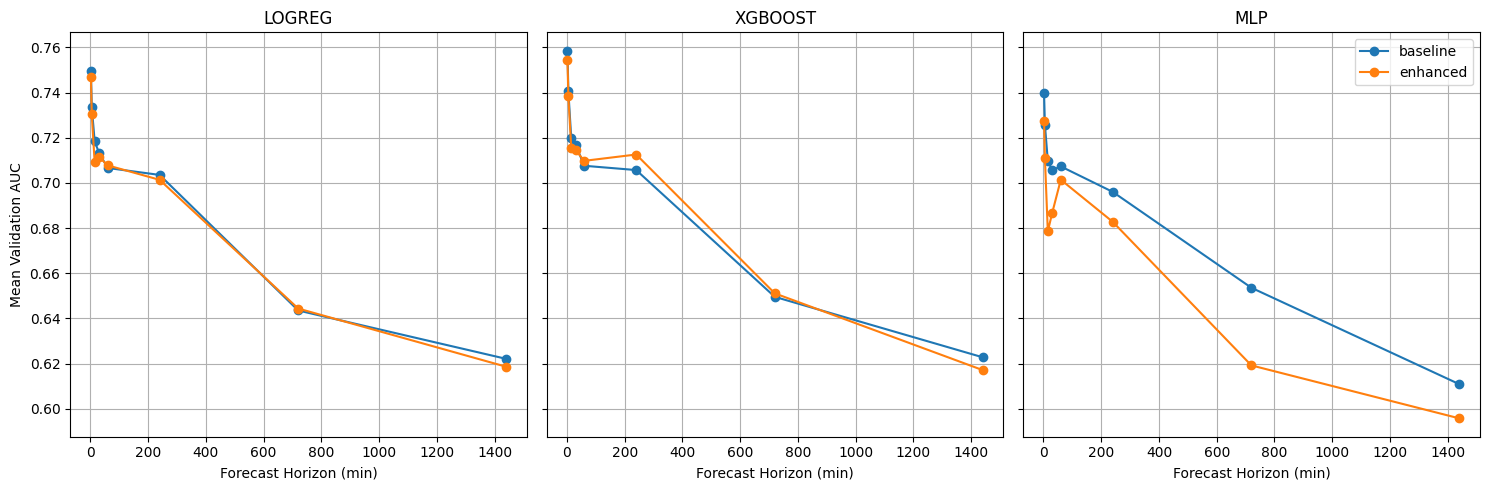

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5),
    sharey=True
)

models = ["logreg", "xgboost", "mlp"]

for ax, model in zip(axes, models):

    tmp = summary_df[
        summary_df["model"] == model
    ]

    for fs in ["baseline", "enhanced"]:

        subset = (
            tmp[tmp["feature_set"] == fs]
            .sort_values("horizon")
        )

        ax.plot(
            subset["horizon"],
            subset["mean_auc"],
            marker="o",
            label=fs
        )

    ax.set_title(model.upper())
    ax.set_xlabel("Forecast Horizon (min)")
    ax.grid(True)

axes[0].set_ylabel("Mean Validation AUC")

plt.legend()

plt.tight_layout()

plt.savefig(
    "auc_by_horizon.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from scipy.stats import wilcoxon

tests = []

for target in results_df["target"].unique():

    for model in results_df["model"].unique():

        base = (
            results_df[
                (results_df["target"] == target)
                &
                (results_df["model"] == model)
                &
                (results_df["feature_set"] == "baseline")
            ]
            .sort_values("fold")
        )

        enh = (
            results_df[
                (results_df["target"] == target)
                &
                (results_df["model"] == model)
                &
                (results_df["feature_set"] == "enhanced")
            ]
            .sort_values("fold")
        )

        diffs = (
            enh["val_auc"].values
            - base["val_auc"].values
        )

        try:

            stat, p = wilcoxon(diffs)

        except:

            stat = np.nan
            p = np.nan

        tests.append({

            "target": target,
            "model": model,
            "mean_delta": diffs.mean(),
            "p_value": p
        })

significance_df = pd.DataFrame(tests)

significance_df.sort_values(
    "mean_delta",
    ascending=False
).head(20)

,target,model,mean_delta,p_value
16,y_up_240,xgboost,0.006887,0.0625
13,y_up_60,xgboost,0.002181,1.0000
19,y_up_720,xgboost,0.001539,1.0000
12,y_up_60,logreg,0.001157,1.0000
18,y_up_720,logreg,0.000857,0.4375
9,y_up_30,logreg,-0.001834,0.8125
15,y_up_240,logreg,-0.002175,0.6250
4,y_up_5,xgboost,-0.002323,0.3125
10,y_up_30,xgboost,-0.002474,0.8125
0,y_up_2,logreg,-0.002553,0.4375


In [ ]:
overall_delta = (
    delta_df["delta_auc"]
    .mean()
)

print(
    f"Average improvement from tweets: {overall_delta:.4f}"
)

Average improvement from tweets: -0.0073


In [ ]:
delta_df.sort_values(
    "delta_auc",
    ascending=False
).head(10)

,target,model,auc_baseline,auc_enhanced,delta_auc,horizon
11,y_up_240,xgboost,0.705691,0.712578,0.006887,240
20,y_up_60,xgboost,0.707595,0.709776,0.002181,60
23,y_up_720,xgboost,0.649567,0.651106,0.001539,720
18,y_up_60,logreg,0.706620,0.707778,0.001157,60
21,y_up_720,logreg,0.643531,0.644388,0.000857,720
12,y_up_30,logreg,0.713346,0.711513,-0.001834,30
9,y_up_240,logreg,0.703543,0.701367,-0.002175,240
17,y_up_5,xgboost,0.740678,0.738355,-0.002323,5
14,y_up_30,xgboost,0.716998,0.714524,-0.002474,30
6,y_up_2,logreg,0.749532,0.746980,-0.002553,2


In [ ]:
tweets.columns

Index(['timestamp_utc', 'clean_text', 'embedding', 'finbert_positive',
       'finbert_neutral', 'finbert_negative', 'finbert_sentiment_score',
       'finbert_entropy', 'finbert_confidence', 'financial_uncertainty_score',
       'financial_risk_sentiment', 'finbert_polarization', 'caps_ratio',
       'exclamation_count', 'exclamation_count_log', 'tweet_length',
       'tweet_length_log', 'market_aggression_index',
       'time_since_last_tweet_min', 'rolling_tweet_frequency_60m',
       'rolling_tweet_frequency_6h', 'rolling_tweet_frequency_24h',
       'tweet_burst_indicator', 'tweet_acceleration_6h',
       'sentiment_delta_vs_previous', 'rolling_sentiment_mean_60m',
       'rolling_sentiment_std_60m', 'is_trump_president', 'wti_bullish_score',
       'wti_bearish_score', 'energy_supply_score',
       'geopolitical_oil_risk_score', 'usd_strength_pressure_score',
       'fed_monetary_policy_score', 'risk_sentiment_score',
       'trump_energy_policy_score', 'trump_market_shock_langua

In [ ]:
tweet_features = [
    'finbert_positive',
    'finbert_neutral',
    'finbert_negative',
    'finbert_sentiment_score',
    'finbert_entropy',
    'finbert_confidence',
    'financial_uncertainty_score',
    'financial_risk_sentiment',
    'finbert_polarization',
    'caps_ratio',
    'exclamation_count',
    'exclamation_count_log',
    'tweet_length',
    'tweet_length_log',
    'market_aggression_index',
    'time_since_last_tweet_min',
    'rolling_tweet_frequency_60m',
    'rolling_tweet_frequency_6h',
    'rolling_tweet_frequency_24h',
    'tweet_burst_indicator',
    'tweet_acceleration_6h',
    'sentiment_delta_vs_previous',
    'rolling_sentiment_mean_60m',
    'rolling_sentiment_std_60m',
    'is_trump_president',
    'wti_bullish_score',
    'wti_bearish_score',
    'energy_supply_score',
    'geopolitical_oil_risk_score',
    'usd_strength_pressure_score',
    'fed_monetary_policy_score',
    'risk_sentiment_score',
    'trump_energy_policy_score',
    'trump_market_shock_language_score',
    'policy_shock_score',
    'dominant_topic',
    'topic_concentration',
    'topic_energy_supply',
    'topic_fed_monetary_policy',
    'topic_geopolitical_oil_risk',
    'topic_policy_shock',
    'topic_risk_sentiment',
    'topic_trump_energy_policy',
    'topic_trump_market_shock_language',
    'topic_usd_strength_pressure',
    'topic_wti_bearish',
    'topic_wti_bullish',
    'semantic_global_novelty',
    'semantic_local_change',
    'semantic_rolling_novelty'
]

In [ ]:
import pandas as pd

shap_rows = []

enhanced = results_df[
    results_df["feature_set"] == "enhanced"
]

for _, row in enhanced.iterrows():

    fi_list = row["feature_importance"]

    if fi_list is None:
        continue

    for item in fi_list:

        shap_rows.append({

            "target": row["target"],
            "model": row["model"],
            "fold": row["fold"],

            "feature": item["feature"],
            "mean_abs_shap": item["mean_abs_shap"]
        })

shap_df = pd.DataFrame(shap_rows)

In [ ]:
global_shap = (
    shap_df
    .groupby("feature", as_index=False)
    ["mean_abs_shap"]
    .mean()
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

global_shap.head(20)

,feature,mean_abs_shap
103,vol_close_60,0.176243
100,vol_close_240,0.093492
8,dow_sin,0.090889
99,vol_close_15,0.082770
2,dayofweek,0.079391
114,was_missing,0.078018
112,vol_ratio_5_60,0.069385
104,vol_cluster,0.066844
101,vol_close_30,0.059722
21,hl_range,0.034311


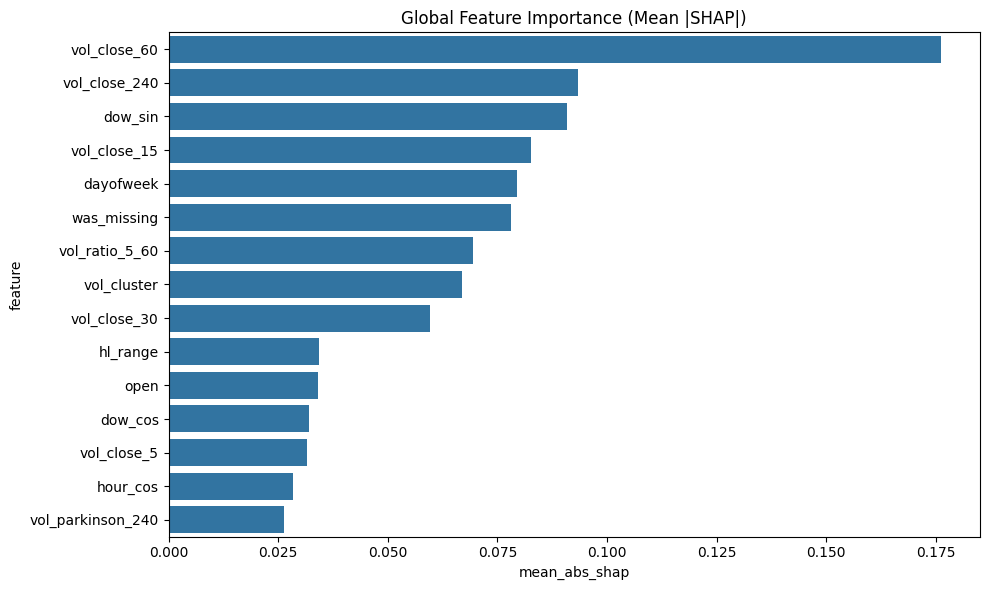

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top15 = global_shap.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top15,
    x="mean_abs_shap",
    y="feature"
)

plt.title(
    "Global Feature Importance (Mean |SHAP|)"
)

plt.tight_layout()

plt.savefig(
    "top15_global_shap.png",
    dpi=300
)

plt.show()

In [ ]:
top20 = global_shap.head(20)

tweet_top20 = top20[
    top20["feature"].isin(tweet_features)
]

print(tweet_top20)

Empty DataFrame
Columns: [feature, mean_abs_shap]
Index: []


In [ ]:
global_shap["feature_group"] = np.where(
    global_shap["feature"].isin(tweet_features),
    "Tweet Features",
    "Market Features"
)

group_shap = (
    global_shap
    .groupby("feature_group")
    ["mean_abs_shap"]
    .sum()
    .reset_index()
)

group_shap["share"] = (
    group_shap["mean_abs_shap"]
    /
    group_shap["mean_abs_shap"].sum()
)

group_shap

,feature_group,mean_abs_shap,share
0,Market Features,1.564872,0.874313
1,Tweet Features,0.224959,0.125687


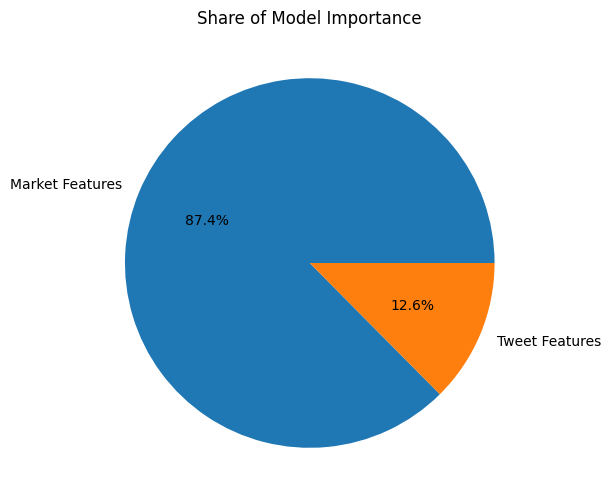

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    group_shap["share"],
    labels=group_shap["feature_group"],
    autopct="%1.1f%%"
)

plt.title(
    "Share of Model Importance"
)

plt.savefig(
    "market_vs_tweet_shap.png",
    dpi=300
)

plt.show()

In [ ]:
tweet_shap = (
    global_shap[
        global_shap["feature"].isin(tweet_features)
    ]
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

tweet_shap.head(15)

,feature,mean_abs_shap,feature_group
70,rolling_tweet_frequency_24h,0.010781,Tweet Features
12,financial_uncertainty_score,0.010488,Tweet Features
94,tweet_length,0.009752,Tweet Features
74,semantic_local_change,0.009023,Tweet Features
75,semantic_rolling_novelty,0.007651,Tweet Features
77,time_since_last_tweet_min,0.007642,Tweet Features
68,rolling_sentiment_mean_60m,0.006850,Tweet Features
92,tweet_acceleration_6h,0.006833,Tweet Features
91,trump_market_shock_language_score,0.006678,Tweet Features
78,topic_concentration,0.006358,Tweet Features


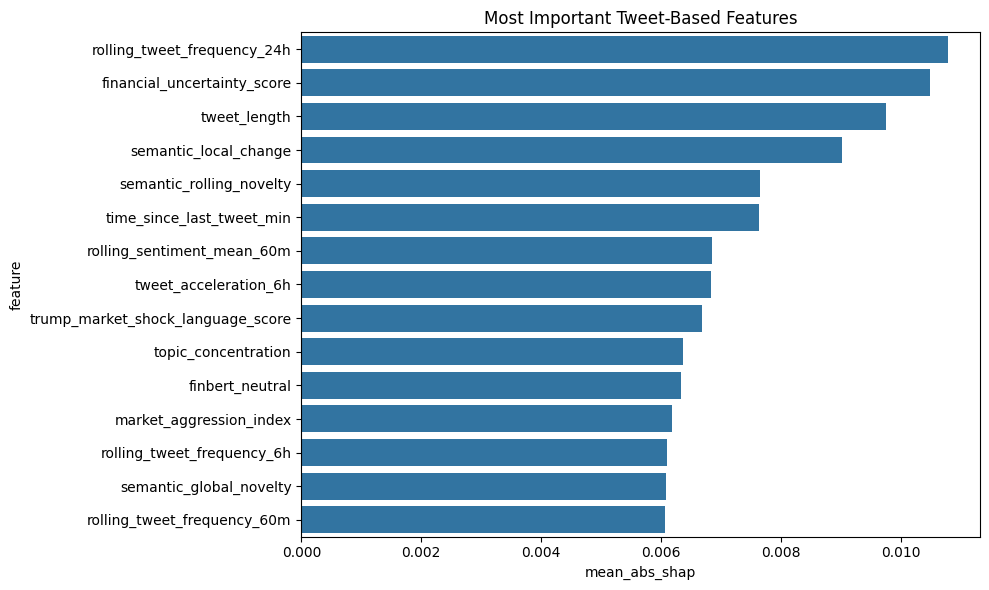

In [ ]:
top_tweet = tweet_shap.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_tweet,
    x="mean_abs_shap",
    y="feature"
)

plt.title(
    "Most Important Tweet-Based Features"
)

plt.tight_layout()

plt.savefig(
    "top_tweet_features.png",
    dpi=300
)

plt.show()

In [ ]:
horizon_shap = []

for target in results_df["target"].unique():

    subset = shap_df[
        shap_df["target"] == target
    ]

    tmp = (
        subset[
            subset["feature"].isin(tweet_features)
        ]
        ["mean_abs_shap"]
        .mean()
    )

    horizon_shap.append({

        "target": target,
        "tweet_shap": tmp
    })

horizon_shap = pd.DataFrame(
    horizon_shap
)

horizon_shap["horizon"] = (
    horizon_shap["target"]
    .str.extract(r"(\d+)")
    .astype(int)
)

horizon_shap = horizon_shap.sort_values(
    "horizon"
)

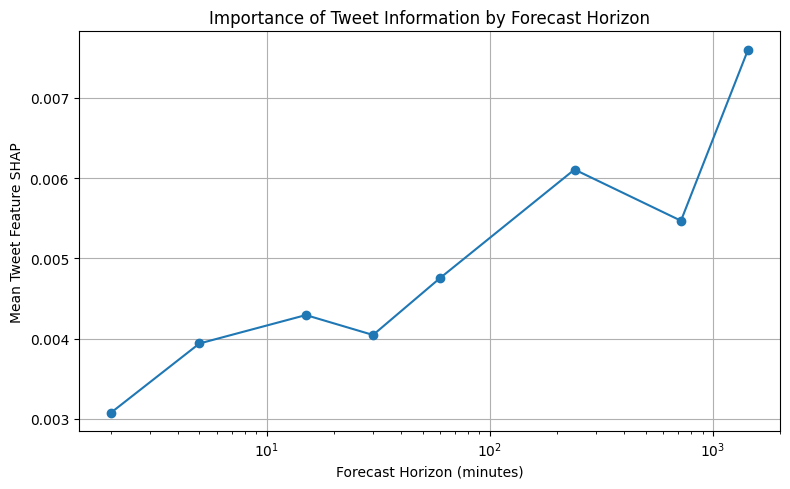

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    horizon_shap["horizon"],
    horizon_shap["tweet_shap"],
    marker="o"
)

plt.xscale("log")

plt.xlabel(
    "Forecast Horizon (minutes)"
)

plt.ylabel(
    "Mean Tweet Feature SHAP"
)

plt.title(
    "Importance of Tweet Information by Forecast Horizon"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "tweet_importance_horizon.png",
    dpi=300
)

plt.show()

In [ ]:
overall_delta = (
    delta_df["delta_auc"]
    .mean()
)

print(
    f"Average improvement from tweets: {overall_delta:.4f}"
)

Average improvement from tweets: -0.0073


In [ ]:
delta_df["horizon"] = (
    delta_df["target"]
    .str.extract(r"(\d+)")
    .astype(int)
)

summary_df["horizon"] = (
    summary_df["target"]
    .str.extract(r"(\d+)")
    .astype(int)
)

# 3. Versuch

In [ ]:
import pandas as pd
import numpy as np


# def aggregate_cv_results(results):

#     rows=[]

#     for r in results.values():
#         # print(type(r), r)
#         rows.append({
#             "target":r["target"],
#             "feature_set":r["feature_set"],
#             "model":r["model"],
#             "fold":r["fold"],
#             "auc":r["val_auc"]
#         })


#     df=pd.DataFrame(rows)

#     return df



#cv_df = aggregate_cv_results(results_df)


summary = (
    results_df
    .groupby(
        [
            "target",
            "feature_set",
            "model"
        ]
    )
    ["val_auc"]
    .agg(
        [
            "mean",
            "std"
        ]
    )
    .reset_index()
)


summary

,target,feature_set,model,mean,std
0,y_up_1440,baseline,logreg,0.622124,0.017323
1,y_up_1440,baseline,mlp,0.610912,0.026363
2,y_up_1440,baseline,xgboost,0.622812,0.036279
3,y_up_1440,enhanced,logreg,0.618640,0.014919
4,y_up_1440,enhanced,mlp,0.595781,0.010132
5,y_up_1440,enhanced,xgboost,0.617144,0.033751
6,y_up_15,baseline,logreg,0.718415,0.009590
7,y_up_15,baseline,mlp,0.709848,0.021663
8,y_up_15,baseline,xgboost,0.719823,0.019266
9,y_up_15,enhanced,logreg,0.709078,0.019587


In [ ]:
pivot = summary.pivot_table(
    index=["target","model"],
    columns="feature_set",
    values="mean"
)


pivot["delta_auc"] = (
    pivot["enhanced"]
    -
    pivot["baseline"]
)


pivot

feature_set        baseline  enhanced  delta_auc
target    model                                 
y_up_1440 logreg   0.622124  0.618640  -0.003484
          mlp      0.610912  0.595781  -0.015131
          xgboost  0.622812  0.617144  -0.005669
y_up_15   logreg   0.718415  0.709078  -0.009337
          mlp      0.709848  0.678555  -0.031293
          xgboost  0.719823  0.715658  -0.004165
y_up_2    logreg   0.749532  0.746980  -0.002553
          mlp      0.739633  0.727313  -0.012319
          xgboost  0.758530  0.754524  -0.004006
y_up_240  logreg   0.703543  0.701367  -0.002175
          mlp      0.696026  0.682766  -0.013259
          xgboost  0.705691  0.712578   0.006887
y_up_30   logreg   0.713346  0.711513  -0.001834
          mlp      0.705663  0.686613  -0.019050
          xgboost  0.716998  0.714524  -0.002474
y_up_5    logreg   0.733464  0.730310  -0.003154
          mlp      0.725673  0.710916  -0.014757
          xgboost  0.740678  0.738355  -0.002323
y_up_60   logreg   0.706620  0.707778   0.001157
          mlp      0.707312  0.701417  -0.005895
          xgboost  0.707595  0.709776   0.002181
y_up_720  logreg   0.643531  0.644388   0.000857
          mlp      0.653591  0.619225  -0.034366
          xgboost  0.649567  0.651106   0.001539

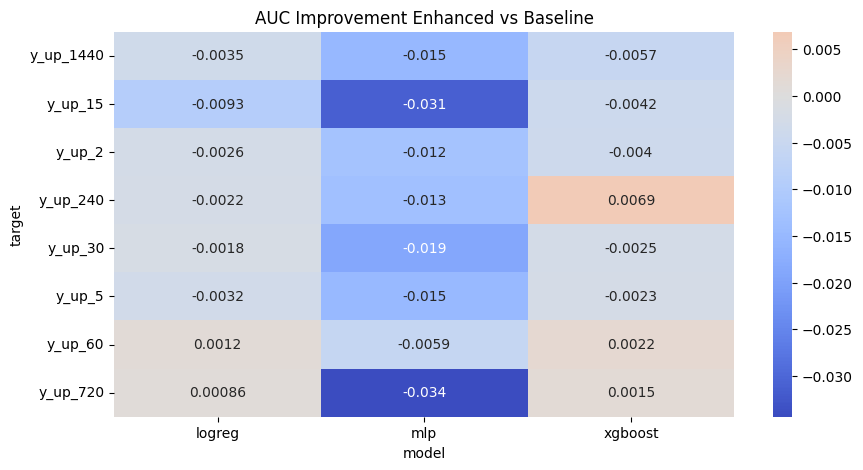

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


heat = (
    pivot
    .reset_index()
    .pivot(
        index="target",
        columns="model",
        values="delta_auc"
    )
)


plt.figure(figsize=(10,5))

sns.heatmap(
    heat,
    annot=True,
    center=0,
    cmap="coolwarm"
)

plt.title(
    "AUC Improvement Enhanced vs Baseline"
)

plt.show()

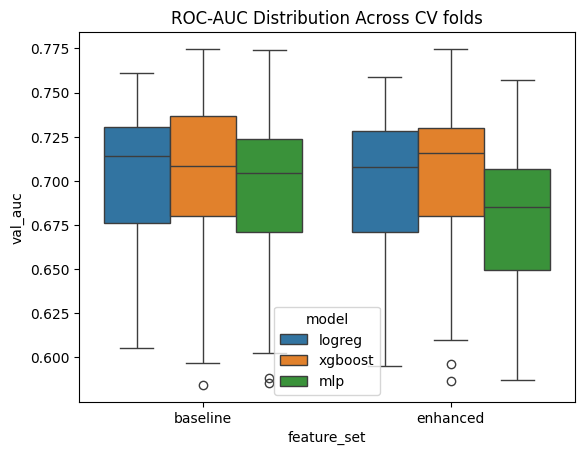

In [ ]:
sns.boxplot(
    data=results_df,
    x="feature_set",
    y="val_auc",
    hue="model"
)

plt.title(
"ROC-AUC Distribution Across CV folds"
)

plt.show()

In [ ]:
best_models = (
    summary
    .sort_values(
        "mean",
        ascending=False
    )
    .groupby(
        ["target","feature_set"]
    )
    .first()
)

best_models

model      mean       std
target    feature_set                             
y_up_1440 baseline     xgboost  0.622812  0.036279
          enhanced      logreg  0.618640  0.014919
y_up_15   baseline     xgboost  0.719823  0.019266
          enhanced     xgboost  0.715658  0.012720
y_up_2    baseline     xgboost  0.758530  0.015670
          enhanced     xgboost  0.754524  0.017118
y_up_240  baseline     xgboost  0.705691  0.009745
          enhanced     xgboost  0.712578  0.006459
y_up_30   baseline     xgboost  0.716998  0.023714
          enhanced     xgboost  0.714524  0.018131
y_up_5    baseline     xgboost  0.740678  0.021116
          enhanced     xgboost  0.738355  0.021575
y_up_60   baseline     xgboost  0.707595  0.016034
          enhanced     xgboost  0.709776  0.016846
y_up_720  baseline         mlp  0.653591  0.014628
          enhanced     xgboost  0.651106  0.019308

## 4. Versuch

In [ ]:
import numpy as np
import pandas as pd

def explode_predictions(results_df):

    rows = []

    for _, row in results_df.iterrows():

        n = len(row["y_val_true"])

        tmp = pd.DataFrame({
            "target": row["target"],
            "feature_set": row["feature_set"],
            "model": row["model"],
            "fold": row["fold"],
            "y_true": row["y_val_true"],
            "y_prob": row["y_val_prob"],
            "feature_timestamp": row["feature_timestamp"],
            "target_timestamp": row["target_timestamp"]
        })

        rows.append(tmp)

    return pd.concat(rows, ignore_index=True)

In [ ]:
def build_auc_summary(results_df):

    summary = (
        results_df
        .groupby(
            ["target","model","feature_set"]
        )["val_auc"]
        .agg(
            mean_auc="mean",
            std_auc="std",
            min_auc="min",
            max_auc="max"
        )
        .reset_index()
    )

    return summary

## Nach dem Training - separate Tabelle

In [ ]:
results = results_df.copy()

In [ ]:
results["feature_importance"]

0      [{'feature': 'was_missing', 'mean_abs_shap': 0...
1      [{'feature': 'was_missing', 'mean_abs_shap': 0...
2      [{'feature': 'vol_close_240', 'mean_abs_shap':...
3      [{'feature': 'was_missing', 'mean_abs_shap': 0...
4      [{'feature': 'dayofweek', 'mean_abs_shap': 0.4...
                             ...                        
235    [{'feature': 'open', 'mean_abs_shap': 0.076760...
236    [{'feature': 'vol_close_240', 'mean_abs_shap':...
237    [{'feature': 'vol_close_240', 'mean_abs_shap':...
238    [{'feature': 'was_missing', 'mean_abs_shap': 0...
239    [{'feature': 'dow_sin', 'mean_abs_shap': 0.069...
Name: feature_importance, Length: 240, dtype: object

In [ ]:
print(type(results))
print(type(results[0]))
print(results[0])

<class 'pandas.DataFrame'>


KeyError: 0

In [ ]:
type(results)

pandas.DataFrame

In [ ]:
# feature_results = []


# for r in results:

#     tmp = pd.DataFrame(
#         r["feature_importance"]
#     )

#     tmp["model"] = r["model"]
#     tmp["fold"] = r["fold"]
#     tmp["target"] = r["target"]

#     feature_results.append(tmp)



# feature_results = pd.concat(
#     feature_results
# )


tmp = results[
    ["model", "fold", "target", "feature_importance"]
].explode("feature_importance")

feature_results = pd.concat(
    [
        tmp.drop(columns="feature_importance"),
        pd.json_normalize(tmp["feature_importance"])
    ],
    axis=1
)

In [ ]:
def build_delta_auc(results_df):

    pivot = (
        results_df
        .pivot_table(
            index=["target","model","fold"],
            columns="feature_set",
            values="val_auc"
        )
        .reset_index()
    )

    pivot["delta_auc"] = (
        pivot["enhanced"]
        - pivot["baseline"]
    )

    return pivot

In [ ]:
delta_auc = build_delta_auc(results)

In [ ]:
delta_auc

feature_set,target,model,fold,baseline,enhanced,delta_auc
0,y_up_1440,logreg,0,0.635111,0.629671,-0.005440
1,y_up_1440,logreg,1,0.610568,0.613685,0.003116
2,y_up_1440,logreg,2,0.605623,0.595333,-0.010290
3,y_up_1440,logreg,3,0.613655,0.622140,0.008484
4,y_up_1440,logreg,4,0.645664,0.632372,-0.013292
...,...,...,...,...,...,...
115,y_up_720,xgboost,0,0.623841,0.629988,0.006147
116,y_up_720,xgboost,1,0.646779,0.630233,-0.016546
117,y_up_720,xgboost,2,0.676733,0.663429,-0.013304
118,y_up_720,xgboost,3,0.631524,0.662975,0.031451


In [ ]:
mean_delta = (
    delta_auc
    .groupby(["target","model"])
    ["delta_auc"]
    .agg(
        mean_delta="mean",
        std_delta="std"
    )
    .reset_index()
)

mean_delta

,target,model,mean_delta,std_delta
0,y_up_1440,logreg,-0.003484,0.009126
1,y_up_1440,mlp,-0.015131,0.021649
2,y_up_1440,xgboost,-0.005669,0.007046
3,y_up_15,logreg,-0.009337,0.011870
4,y_up_15,mlp,-0.031293,0.027460
5,y_up_15,xgboost,-0.004165,0.010032
6,y_up_2,logreg,-0.002553,0.006093
7,y_up_2,mlp,-0.012319,0.016576
8,y_up_2,xgboost,-0.004006,0.004233
9,y_up_240,logreg,-0.002175,0.005759


In [ ]:
win_rate = (
    delta_auc
    .groupby(["target","model"])
    ["delta_auc"]
    .apply(lambda x: (x > 0).mean())
    .reset_index(name="win_rate")
)

win_rate

,target,model,win_rate
0,y_up_1440,logreg,0.4
1,y_up_1440,mlp,0.2
2,y_up_1440,xgboost,0.2
3,y_up_15,logreg,0.0
4,y_up_15,mlp,0.0
5,y_up_15,xgboost,0.4
6,y_up_2,logreg,0.4
7,y_up_2,mlp,0.2
8,y_up_2,xgboost,0.0
9,y_up_240,logreg,0.2


In [ ]:
def extract_feature_importances(results):

    dfs = []

    for _, row in results.iterrows():

        imp = pd.DataFrame(
            row["feature_importance"]
        )

        imp["target"] = row["target"]
        imp["model"] = row["model"]
        imp["fold"] = row["fold"]
        imp["feature_set"] = row["feature_set"]

        dfs.append(imp)

    return pd.concat(dfs, ignore_index=True)

In [ ]:
importance_df = extract_feature_importances(results)

In [ ]:
enhanced_importance = (
    importance_df
    .query("feature_set == 'enhanced'")
)

In [ ]:
global_importance = (
    enhanced_importance
    .groupby("feature")
    ["mean_abs_shap"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

global_importance.head(30)

,feature,mean_abs_shap
0,vol_close_60,0.176243
1,vol_close_240,0.093492
2,dow_sin,0.090889
3,vol_close_15,0.082770
4,dayofweek,0.079391
5,was_missing,0.078018
6,vol_ratio_5_60,0.069385
7,vol_cluster,0.066844
8,vol_close_30,0.059722
9,hl_range,0.034311


In [ ]:
def collect_predictions(
    results,
    target,
    model,
    feature_set
):

    subset = results[
        (results["target"] == target)
        &
        (results["model"] == model)
        &
        (results["feature_set"] == feature_set)
    ].sort_values("fold")

    y_true = np.concatenate(
        subset["y_val_true"].values
    )

    y_prob = np.concatenate(
        subset["y_val_prob"].values
    )

    timestamps = np.concatenate(
        subset["feature_timestamp"].values
    )

    return pd.DataFrame({
        "timestamp": timestamps,
        "y_true": y_true,
        "y_prob": y_prob
    })

In [ ]:
baseline_pred = collect_predictions(
    results,
    target="y_up_60",
    model="xgboost",
    feature_set="baseline"
)

enhanced_pred = collect_predictions(
    results,
    target="y_up_60",
    model="xgboost",
    feature_set="enhanced"
)

## 5. Versuch

In [ ]:
results_df = pd.DataFrame(results)

summary = (
    results_df
    .groupby(
        ["target","model","feature_set"]
    )["val_auc"]
    .mean()
    .reset_index()
)

summary = (
    summary
    .pivot_table(
        index=["target","model"],
        columns="feature_set",
        values="val_auc"
    )
    .reset_index()
)

summary["delta_auc"] = (
    summary["enhanced"]
    - summary["baseline"]
)

summary

feature_set,target,model,baseline,enhanced,delta_auc
0,y_up_1440,logreg,0.622124,0.618640,-0.003484
1,y_up_1440,mlp,0.610912,0.595781,-0.015131
2,y_up_1440,xgboost,0.622812,0.617144,-0.005669
3,y_up_15,logreg,0.718415,0.709078,-0.009337
4,y_up_15,mlp,0.709848,0.678555,-0.031293
5,y_up_15,xgboost,0.719823,0.715658,-0.004165
6,y_up_2,logreg,0.749532,0.746980,-0.002553
7,y_up_2,mlp,0.739633,0.727313,-0.012319
8,y_up_2,xgboost,0.758530,0.754524,-0.004006
9,y_up_240,logreg,0.703543,0.701367,-0.002175


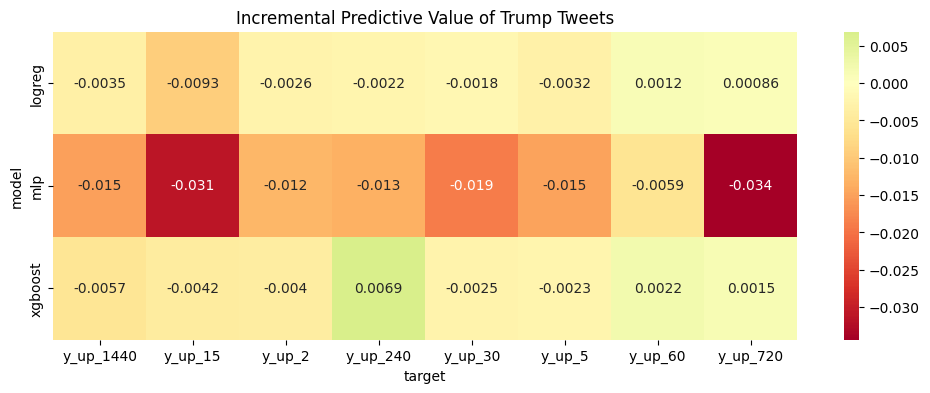

In [ ]:
import seaborn as sns

heatmap = (
    summary
    .pivot(
        index="model",
        columns="target",
        values="delta_auc"
    )
)

plt.figure(figsize=(12,4))
sns.heatmap(
    heatmap,
    annot=True,
    cmap="RdYlGn",
    center=0
)
plt.title("Incremental Predictive Value of Trump Tweets")
plt.show()

In [ ]:
merged = (
    results_df
    .pivot_table(
        index=["target","model","fold"],
        columns="feature_set",
        values="val_auc"
    )
    .reset_index()
)

merged["delta_auc"] = (
    merged["enhanced"]
    - merged["baseline"]
)

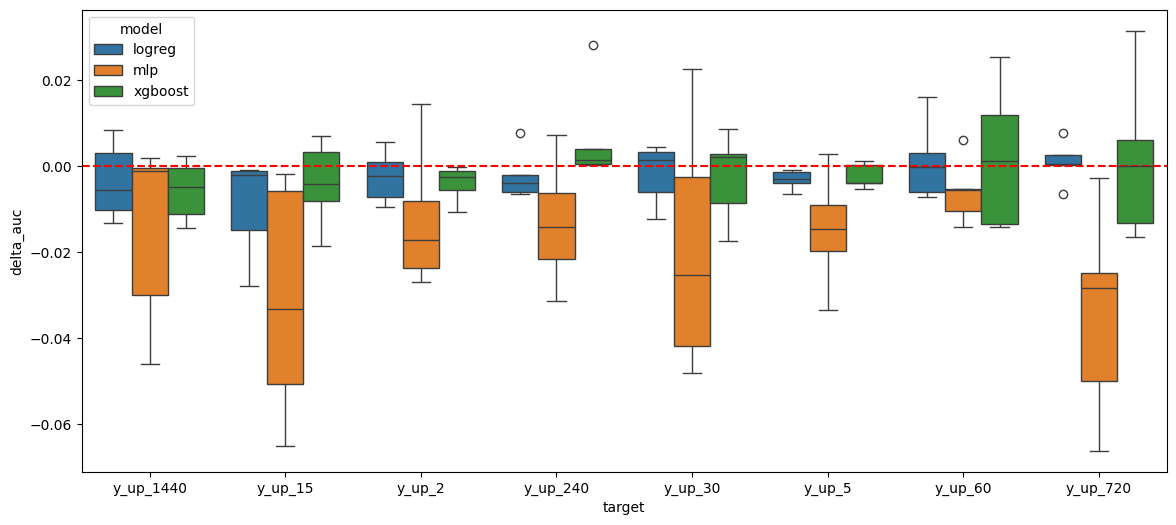

In [ ]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=merged,
    x="target",
    y="delta_auc",
    hue="model"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

In [ ]:
from scipy.stats import wilcoxon

tests = []

for target in merged.target.unique():

    for model in merged.model.unique():

        tmp = merged[
            (merged.target==target)
            &
            (merged.model==model)
        ]

        stat,p = wilcoxon(
            tmp["enhanced"],
            tmp["baseline"]
        )

        tests.append({
            "target":target,
            "model":model,
            "p_value":p,
            "mean_delta":
                tmp["delta_auc"].mean()
        })

tests = pd.DataFrame(tests)

In [ ]:
tests

,target,model,p_value,mean_delta
0,y_up_1440,logreg,0.4375,-0.003484
1,y_up_1440,mlp,0.3125,-0.015131
2,y_up_1440,xgboost,0.1875,-0.005669
3,y_up_15,logreg,0.0625,-0.009337
4,y_up_15,mlp,0.0625,-0.031293
5,y_up_15,xgboost,0.4375,-0.004165
6,y_up_2,logreg,0.4375,-0.002553
7,y_up_2,mlp,0.1875,-0.012319
8,y_up_2,xgboost,0.0625,-0.004006
9,y_up_240,logreg,0.6250,-0.002175


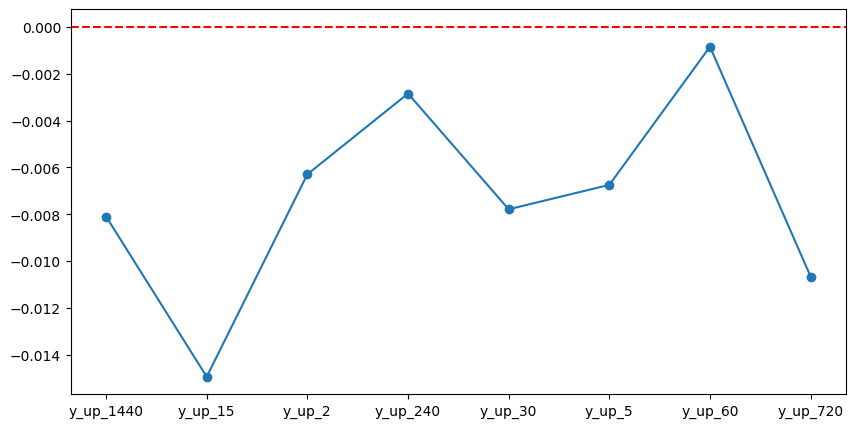

In [ ]:
horizon_perf = (
    summary
    .groupby("target")
    ["delta_auc"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    horizon_perf.index,
    horizon_perf.values,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    color="red"
)

In [ ]:
rows = []

for _, row in results_df.iterrows():

    if row["feature_set"] != "enhanced":
        continue

    imp = pd.DataFrame(
        row["feature_importance"]
    )

    imp["target"] = row["target"]
    imp["model"] = row["model"]

    rows.append(imp)

importance_df = pd.concat(rows)

In [ ]:
global_imp = (
    importance_df
    .groupby("feature")
    ["mean_abs_shap"]
    .mean()
    .sort_values(ascending=False)
)

<Axes: ylabel='feature'>

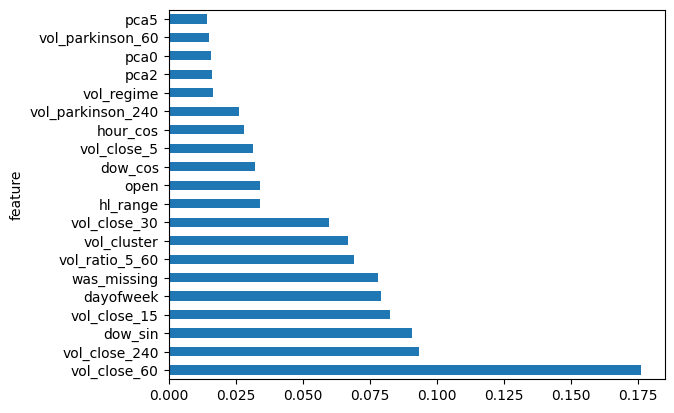

In [ ]:
global_imp.head(20).plot.barh()

In [ ]:
tweet_features = [

    c for c in global_imp.index

    if (
        "finbert" in c
        or "tweet" in c
        or "topic_" in c
        or "semantic_" in c
        or "risk_" in c
        or "policy_" in c
        or "emb_" in c
        or "pca" in c
    )
]

In [ ]:
global_imp.loc[tweet_features].head(20)

feature
pca2                           0.016220
pca0                           0.015944
pca5                           0.014251
pca3                           0.014099
pca28                          0.014082
pca6                           0.013557
pca18                          0.013131
pca8                           0.012708
pca9                           0.012681
pca29                          0.011877
pca12                          0.011825
pca13                          0.011664
pca7                           0.011659
pca16                          0.011556
pca19                          0.011208
rolling_tweet_frequency_24h    0.010781
pca1                           0.010489
pca24                          0.010316
pca27                          0.010003
pca20                          0.009922
Name: mean_abs_shap, dtype: float64

In [ ]:
def classify_feature(x):

    tweet_keywords = [
        "finbert",
        "tweet",
        "topic_",
        "semantic_",
        "risk_",
        "policy_",
        "pca"
    ]

    if any(k in x for k in tweet_keywords):
        return "tweet"

    return "market"

In [ ]:
importance_df["group"] = (
    importance_df["feature"]
    .apply(classify_feature)
)

group_imp = (
    importance_df
    .groupby("group")
    ["mean_abs_shap"]
    .sum()
)

<Axes: >

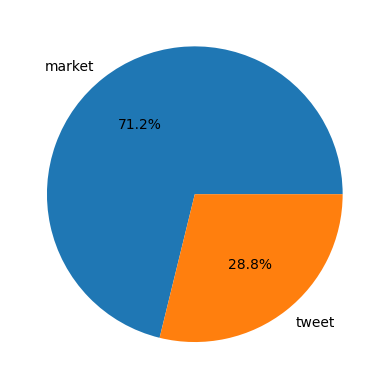

In [ ]:
group_imp.plot.pie(
    autopct="%.1f%%"
)

## Für die Thesis ergänzen

In [ ]:
feature_results.to_parquet(
    "feature_importance_shap.parquet"
)

In [ ]:
importance["feature_group"] = (
    importance["feature"]
    .apply(
        lambda x:
        "tweet"
        if "finbert" in x
        or "tweet" in x
        or "sentiment" in x
        else "market"
    )
)

NameError: name 'importance' is not defined

Dann kannst du später direkt testen:

"Wie viel SHAP Importance kommt aus Tweet Features?"

und kannst sauber zeigen:

"Tweet-Features erklären X% der Modellentscheidung und erhöhen die Out-of-Sample Prognosegüte um ΔAUC."

# Extrahierung der Coefficients für LogReg!

In [ ]:
model = models[("y_up_2", "enhanced", "logreg", 1)]["model"] # .named_steps["preprocessor"].get_feature_names_out()

In [ ]:
# Namen nach ColumnTransformer
names = (
    model
    .named_steps["preprocessor"]
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [ ]:
names

array(['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7',
       'pca8', 'pca9', 'pca10', 'pca11', 'pca12', 'pca13', 'pca14',
       'pca15', 'pca16', 'pca17', 'pca18', 'pca19', 'pca20', 'pca21',
       'pca22', 'pca23', 'pca24', 'pca25', 'pca26', 'pca27', 'pca28',
       'pca29', 'finbert_positive', 'finbert_neutral', 'finbert_negative',
       'finbert_sentiment_score', 'finbert_entropy', 'finbert_confidence',
       'finbert_polarization', 'financial_uncertainty_score',
       'financial_risk_sentiment', 'caps_ratio', 'exclamation_count',
       'exclamation_count_log', 'tweet_length', 'tweet_length_log',
       'market_aggression_index', 'time_since_last_tweet_min',
       'rolling_tweet_frequency_60m', 'rolling_tweet_frequency_6h',
       'rolling_tweet_frequency_24h', 'tweet_burst_indicator',
       'tweet_acceleration_6h', 'sentiment_delta_vs_previous',
       'rolling_sentiment_mean_60m', 'rolling_sentiment_std_60m',
       'is_trump_president', 'wti_bullish_score'

In [ ]:
variance_mask = (
    model
    .named_steps["preprocessor"]
    .named_steps["variance"]
    .get_support()
)

after_variance = names[variance_mask]

In [ ]:
corr_mask = (
    model
    .named_steps["preprocessor"]
    .named_steps["corr"]
    .keep_mask_
)

final_features = after_variance[corr_mask]

In [ ]:
len(final_features)

114

In [ ]:
model_logreg = model.named_steps["model"]

coefs = model_logreg.coef_[0]

In [ ]:
model_logreg.coef_[0]

array([ 0.00472367, -0.00476183,  0.00286552,  0.00037928,  0.        ,
        0.        ,  0.00974395,  0.        , -0.01643888,  0.        ,
        0.        ,  0.        ,  0.        , -0.02231857, -0.00087289,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [ ]:
len(coefs)

114

In [ ]:
importance = pd.DataFrame({
    "feature": final_features,
    "coefficient": coefs,
    "importance_abs": np.abs(coefs)
})

importance = (
    importance
    .sort_values(
        "importance_abs",
        ascending=False
    )
)

In [ ]:
print(importance.to_string())

                               feature  coefficient  importance_abs
75                         was_missing    -0.369078        0.369078
105                          dayofweek    -0.203006        0.203006
94                      vol_ratio_5_60     0.187429        0.187429
88                        vol_close_30     0.131700        0.131700
91                       vol_close_240     0.128282        0.128282
112                         vol_regime     0.101152        0.101152
111                           vol_rank     0.053526        0.053526
108                            dow_sin     0.043394        0.043394
107                           hour_cos    -0.039493        0.039493
113                       trend_regime     0.037526        0.037526
13                               pca13    -0.022319        0.022319
8                                 pca8    -0.016439        0.016439
6                                 pca6     0.009744        0.009744
1                                 pca1    -0.004

### Post Analysis Module

Model Ranking

In [ ]:
def rank_models(results_df):
    return results_df.groupby(["model", "feature_set"]).mean()

Stability Analysis

In [ ]:
def fold_stability(results_df):
    return results_df.groupby("model")["roc_auc"].std()

Prediction Drift

In [ ]:
def plot_time_performance(predictions_df):

    df = pd.DataFrame(predictions_df)
    df["correct"] = df["y_pred"] == df["y_true"]

    return df.groupby("fold")["correct"].mean()

SHAP (after training only)

In [ ]:
import shap

def shap_analysis(model, X):

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    shap.summary_plot(shap_values, X)